<a href="https://www.kaggle.com/code/lalit7881/tiktok-instagram-addiction2015-60-eda-100?scriptVersionId=323911280" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from math import pi
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/abdulmaliklodhra/tiktok-and-instagram-addiction-dataset-20152060/country_wise_analysis_addiction.csv
/kaggle/input/datasets/abdulmaliklodhra/tiktok-and-instagram-addiction-dataset-20152060/Cover_Global_Tiktok_Instagram_Addiction_(2015-2060).png
/kaggle/input/datasets/abdulmaliklodhra/tiktok-and-instagram-addiction-dataset-20152060/tiktok_instagram_global_100countries.csv
/kaggle/input/datasets/abdulmaliklodhra/tiktok-and-instagram-addiction-dataset-20152060/screen_time_behavior.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/abdulmaliklodhra/tiktok-and-instagram-addiction-dataset-20152060/tiktok_instagram_global_100countries.csv")

In [3]:
df.head()

,user_id,country,age,year,internet_penetration,mental_health_support_index,gdp_index,youth_population_ratio,baseline_addiction_pressure,tiktok_minutes_daily,...,addiction_pressure,attention_span_score,dopamine_dependency_score,impulsivity_index,sleep_hours,sleep_quality_index,ASI,MHRI,addiction_score,addiction_level
0,1,Philippines,59,2050,88.895513,64.347080,0.312067,0.310389,64.762693,242.853130,...,69.981792,77.479304,27.024835,60.044856,6.561778,7.912360,100.0,40.460626,63.512418,High
1,2,Netherlands,23,2035,57.950292,76.257045,0.460320,0.293134,37.592646,98.599951,...,56.862382,78.852713,25.376744,81.769114,9.400197,2.292106,100.0,79.424028,62.688372,High
2,3,Laos,26,2060,40.325805,55.846514,0.893658,0.183055,22.589595,127.221573,...,41.817693,83.573012,19.712386,99.613065,7.810417,2.308761,100.0,88.262729,59.856193,High
3,4,Bulgaria,50,2046,43.838044,28.390576,0.661523,0.155038,57.093084,140.528514,...,70.811984,83.437675,19.874790,86.935944,7.020033,4.512440,100.0,70.905771,59.937395,High
4,5,Zambia,24,2045,43.749943,81.413755,0.275186,0.457115,57.653485,187.748696,...,71.990949,71.993561,33.607727,45.275020,7.900621,4.265014,100.0,51.312439,66.803864,High


In [4]:
df.tail()

,user_id,country,age,year,internet_penetration,mental_health_support_index,gdp_index,youth_population_ratio,baseline_addiction_pressure,tiktok_minutes_daily,...,addiction_pressure,attention_span_score,dopamine_dependency_score,impulsivity_index,sleep_hours,sleep_quality_index,ASI,MHRI,addiction_score,addiction_level
9995,9996,Cambodia,30,2019,88.112224,35.854704,0.930592,0.389052,73.468587,138.532061,...,88.124399,87.352146,15.177425,68.300175,7.762866,4.137675,100.0,63.461711,57.588712,High
9996,9997,Nepal,44,2021,75.276099,88.995532,0.335594,0.174699,26.671849,109.827675,...,34.390640,84.661070,18.406715,24.921506,6.227259,6.912484,100.0,27.898335,59.203358,High
9997,9998,Brazil,44,2039,75.320851,55.599948,0.918843,0.373100,69.587448,157.642548,...,73.780044,77.524906,26.970113,46.063910,8.612393,8.322962,100.0,31.417147,63.485057,High
9998,9999,Iceland,57,2022,41.499728,82.096050,0.698312,0.412805,78.463688,89.940360,...,79.496451,83.099185,20.280978,80.615419,4.786482,9.586895,100.0,42.373235,60.140489,High
9999,10000,Bolivia,48,2048,81.776282,25.388594,0.328646,0.244791,25.477201,96.210561,...,40.584723,85.108617,17.869659,70.945695,7.560006,3.956991,100.0,65.687893,58.934830,High


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      10000 non-null  int64  
 1   country                      10000 non-null  object 
 2   age                          10000 non-null  int64  
 3   year                         10000 non-null  int64  
 4   internet_penetration         10000 non-null  float64
 5   mental_health_support_index  10000 non-null  float64
 6   gdp_index                    10000 non-null  float64
 7   youth_population_ratio       10000 non-null  float64
 8   baseline_addiction_pressure  10000 non-null  float64
 9   tiktok_minutes_daily         10000 non-null  float64
 10  instagram_minutes_daily      10000 non-null  float64
 11  night_usage_ratio            10000 non-null  float64
 12  scroll_velocity              10000 non-null  float64
 13  addiction_pressur

In [6]:
df.describe()

,user_id,age,year,internet_penetration,mental_health_support_index,gdp_index,youth_population_ratio,baseline_addiction_pressure,tiktok_minutes_daily,instagram_minutes_daily,...,scroll_velocity,addiction_pressure,attention_span_score,dopamine_dependency_score,impulsivity_index,sleep_hours,sleep_quality_index,ASI,MHRI,addiction_score
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,35.744800,2037.435100,67.947220,55.188221,0.614310,0.320566,51.085025,120.918463,100.110930,...,2.994107,61.172388,81.580884,22.102939,49.826549,6.995095,5.965055,94.987625,45.088001,58.545282
std,2886.89568,13.495551,13.220419,17.376643,20.446164,0.232364,0.101786,19.130635,58.319304,49.319921,...,0.981106,20.055079,6.415993,7.699192,29.089913,1.463732,2.293633,12.657189,18.600882,9.269489
min,1.00000,13.000000,2015.000000,40.325805,20.486649,0.204049,0.155038,20.650259,0.000000,0.000000,...,0.500000,20.773034,58.105040,0.000000,0.014594,3.000000,2.001108,8.034107,0.889433,4.144855
25%,2500.75000,24.000000,2026.000000,51.562989,36.943869,0.424618,0.236706,33.415750,79.605389,66.098259,...,2.330494,43.609519,77.193445,16.754094,24.664459,5.994770,3.971535,100.000000,31.559304,57.958516
50%,5000.50000,35.000000,2037.000000,67.860681,55.599948,0.654647,0.326098,51.662067,120.423637,99.610582,...,2.996064,61.646903,81.671635,21.994038,49.466435,6.992438,5.965669,100.000000,45.112710,60.997019
75%,7500.25000,47.000000,2049.000000,83.046765,74.591288,0.797193,0.407275,68.767974,161.257721,133.416931,...,3.660483,78.594144,86.038255,27.367867,75.301112,8.039537,7.933711,100.000000,58.692734,63.683933
max,10000.00000,59.000000,2060.000000,98.226329,88.995532,0.992043,0.496677,79.577888,356.310179,277.104751,...,6.554050,99.289863,100.000000,50.273952,99.989292,10.000000,9.998968,100.000000,88.944863,75.136976


In [7]:
df.isnull().sum()

user_id                        0
country                        0
age                            0
year                           0
internet_penetration           0
mental_health_support_index    0
gdp_index                      0
youth_population_ratio         0
baseline_addiction_pressure    0
tiktok_minutes_daily           0
instagram_minutes_daily        0
night_usage_ratio              0
scroll_velocity                0
addiction_pressure             0
attention_span_score           0
dopamine_dependency_score      0
impulsivity_index              0
sleep_hours                    0
sleep_quality_index            0
ASI                            0
MHRI                           0
addiction_score                0
addiction_level                0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

user_id                          int64
country                         object
age                              int64
year                             int64
internet_penetration           float64
mental_health_support_index    float64
gdp_index                      float64
youth_population_ratio         float64
baseline_addiction_pressure    float64
tiktok_minutes_daily           float64
instagram_minutes_daily        float64
night_usage_ratio              float64
scroll_velocity                float64
addiction_pressure             float64
attention_span_score           float64
dopamine_dependency_score      float64
impulsivity_index              float64
sleep_hours                    float64
sleep_quality_index            float64
ASI                            float64
MHRI                           float64
addiction_score                float64
addiction_level                 object
dtype: object

In [10]:
df.shape

(10000, 23)

In [11]:
df.columns

Index(['user_id', 'country', 'age', 'year', 'internet_penetration',
       'mental_health_support_index', 'gdp_index', 'youth_population_ratio',
       'baseline_addiction_pressure', 'tiktok_minutes_daily',
       'instagram_minutes_daily', 'night_usage_ratio', 'scroll_velocity',
       'addiction_pressure', 'attention_span_score',
       'dopamine_dependency_score', 'impulsivity_index', 'sleep_hours',
       'sleep_quality_index', 'ASI', 'MHRI', 'addiction_score',
       'addiction_level'],
      dtype='object')

In [12]:
df.nunique()

user_id                        10000
country                          100
age                               47
year                              46
internet_penetration             100
mental_health_support_index      100
gdp_index                        100
youth_population_ratio           100
baseline_addiction_pressure      100
tiktok_minutes_daily            9792
instagram_minutes_daily         9756
night_usage_ratio              10000
scroll_velocity                 9939
addiction_pressure             10000
attention_span_score            9996
dopamine_dependency_score       9996
impulsivity_index              10000
sleep_hours                     9731
sleep_quality_index            10000
ASI                             2244
MHRI                           10000
addiction_score                10000
addiction_level                    4
dtype: int64

## EDA

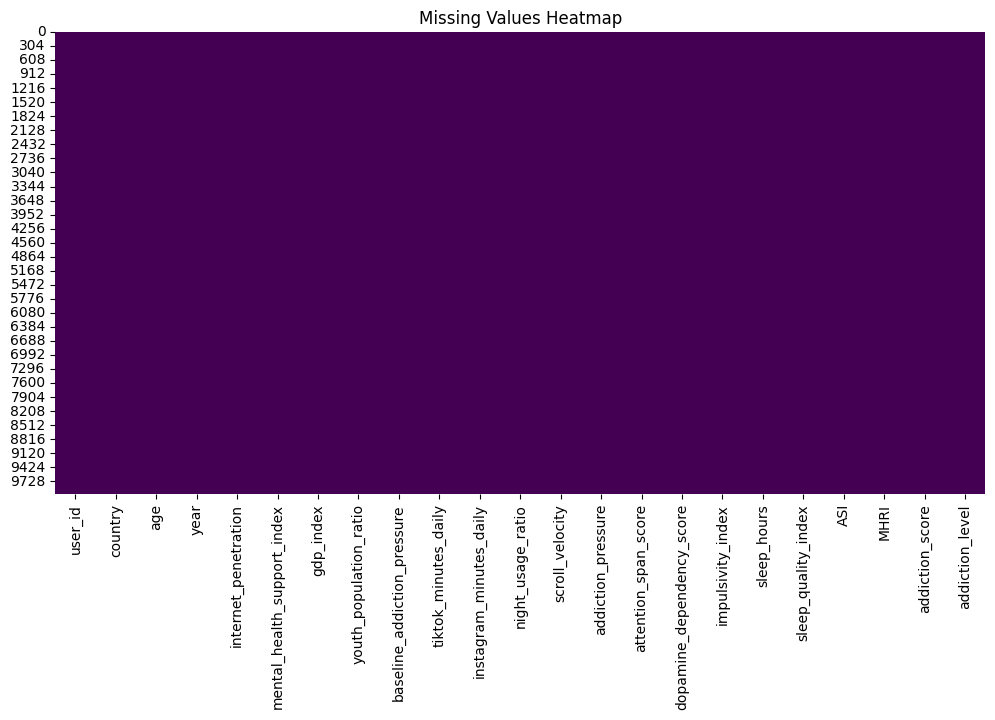

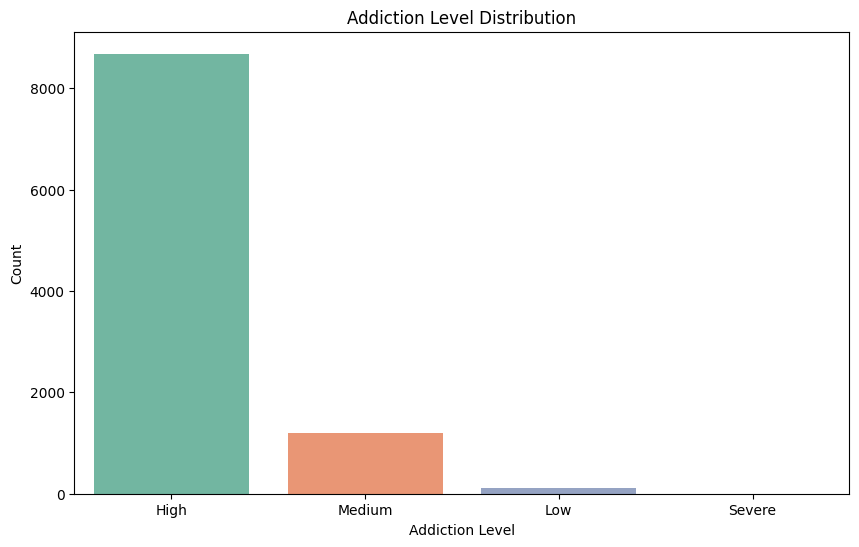

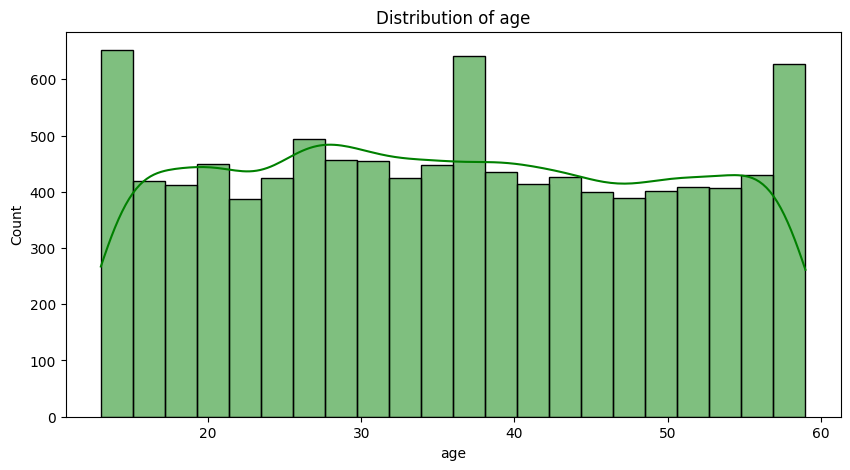

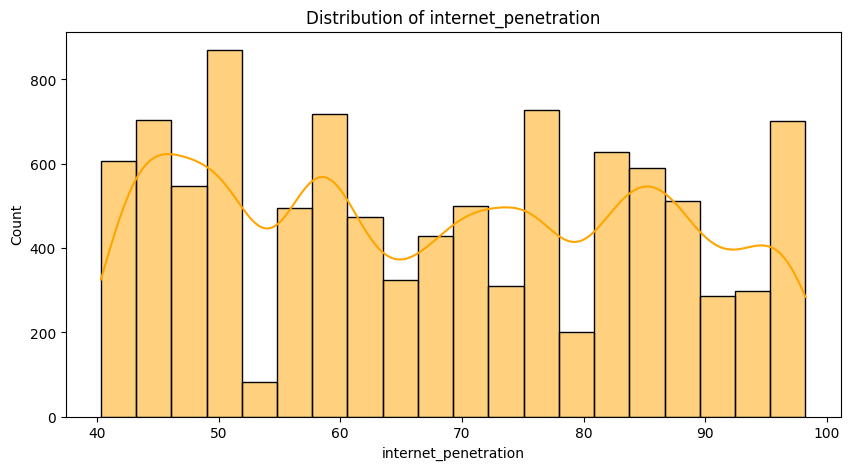

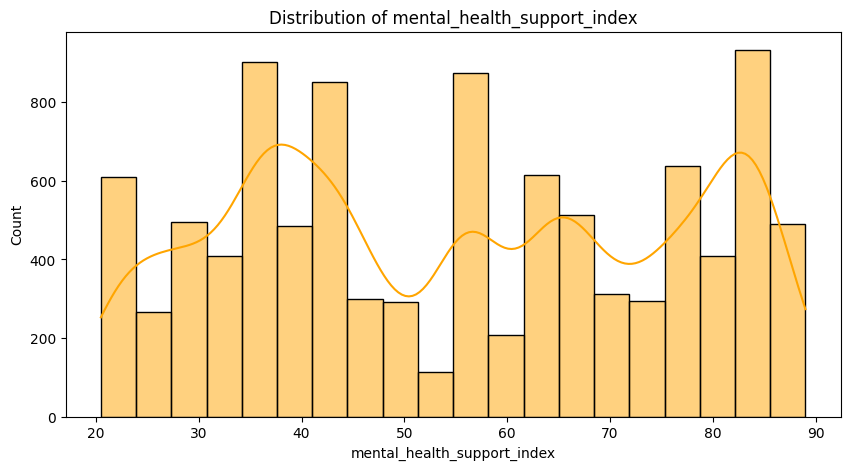

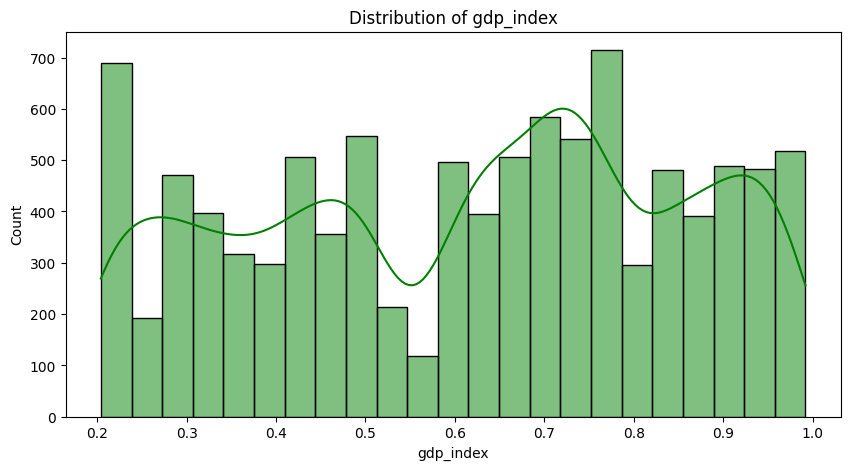

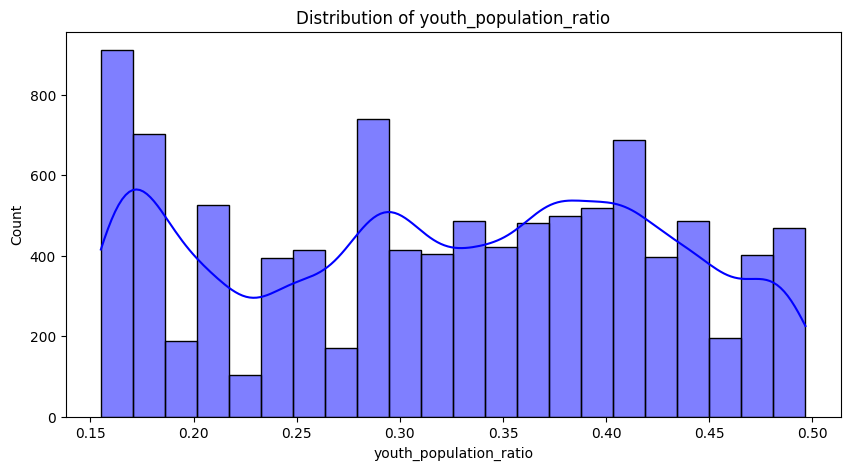

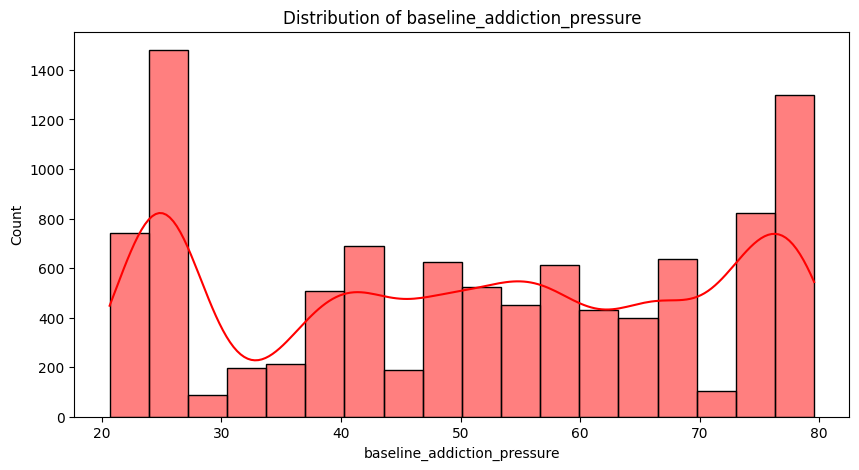

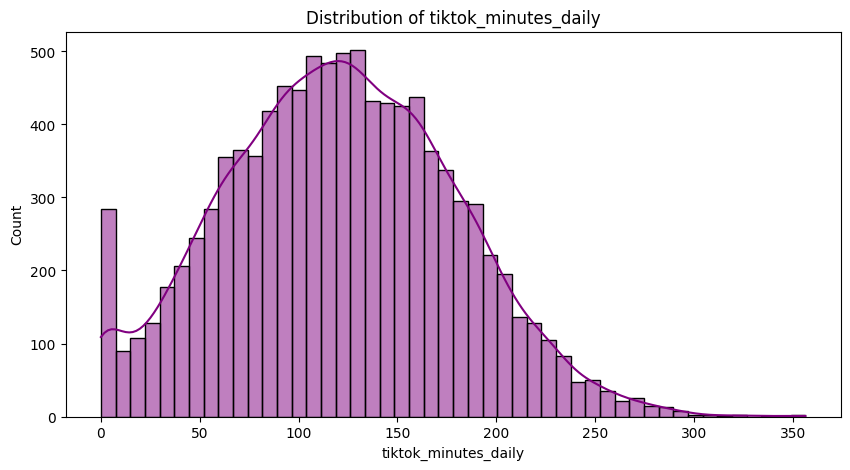

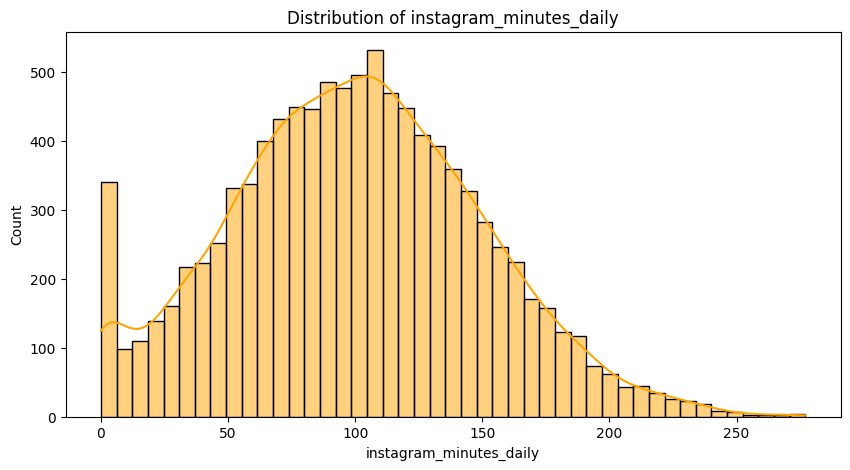

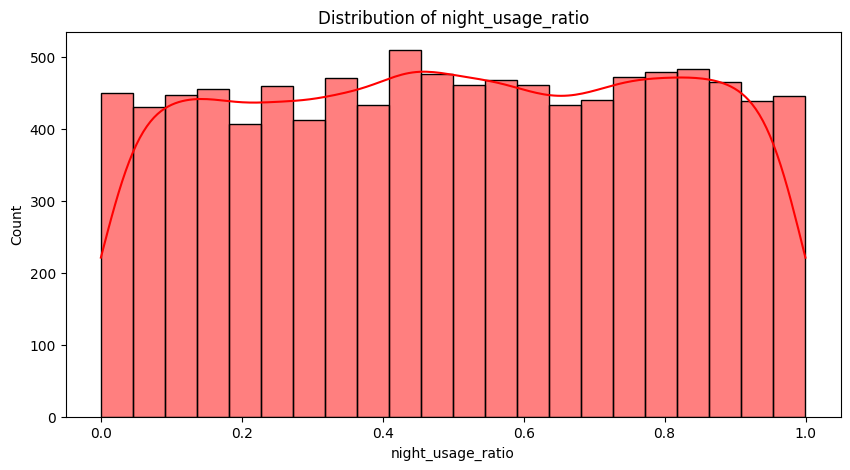

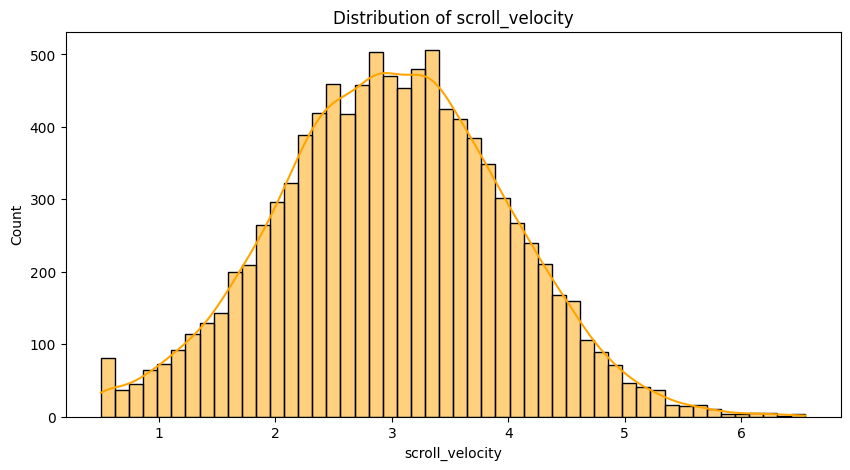

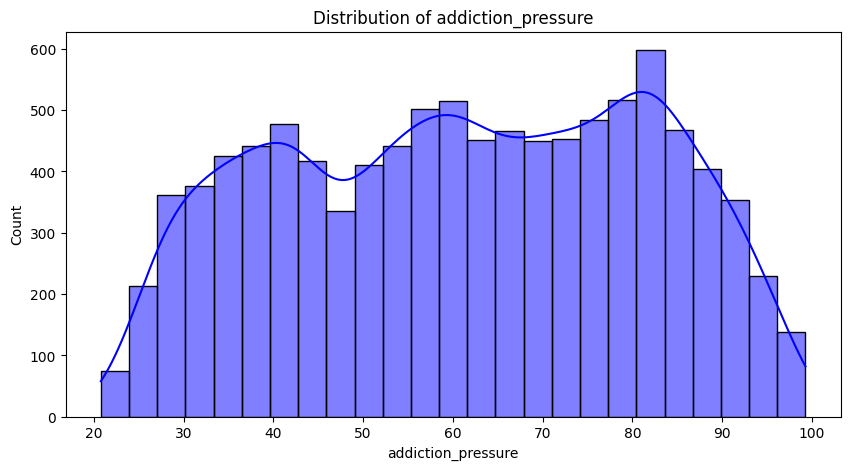

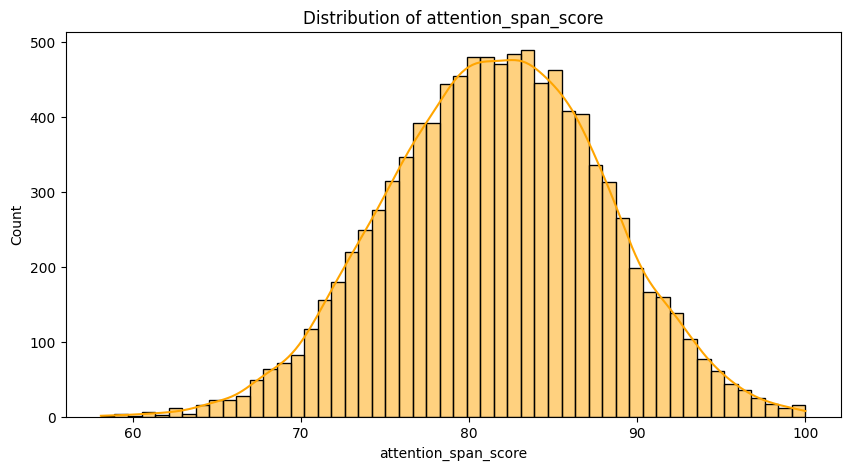

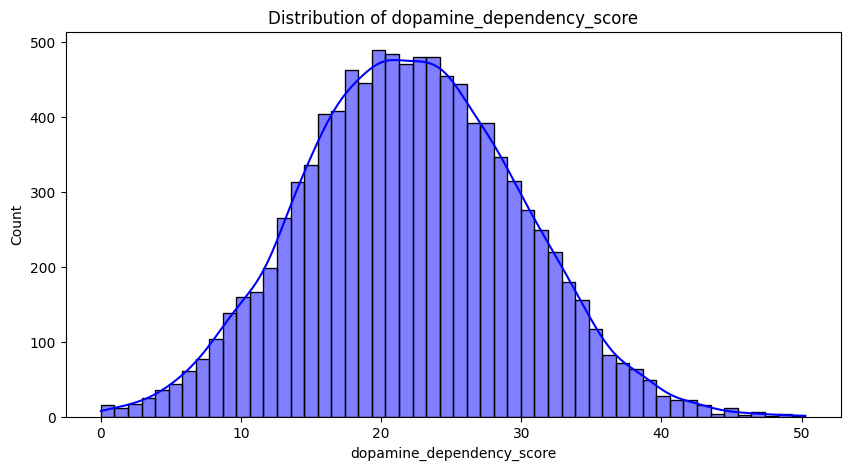

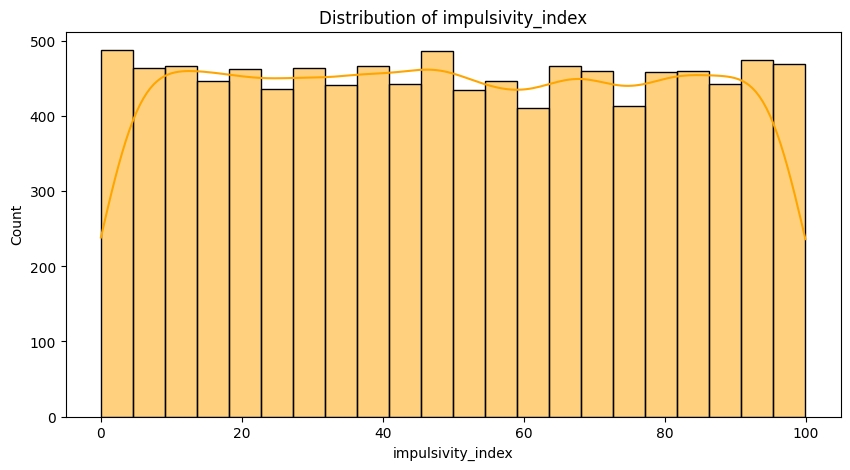

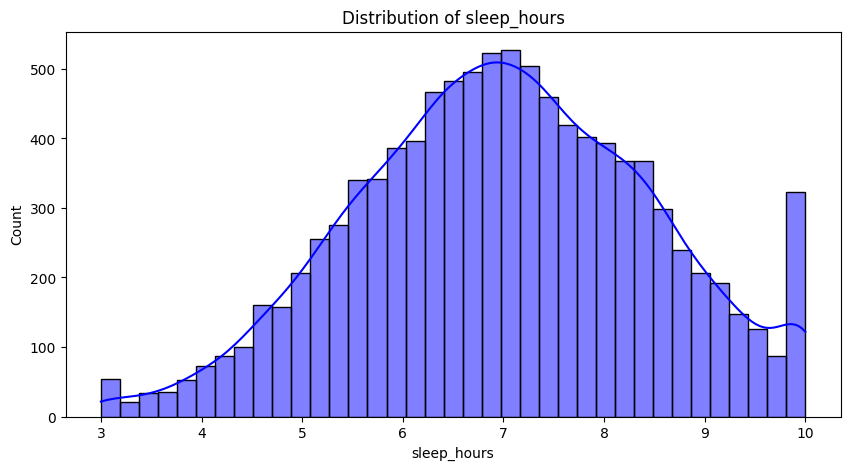

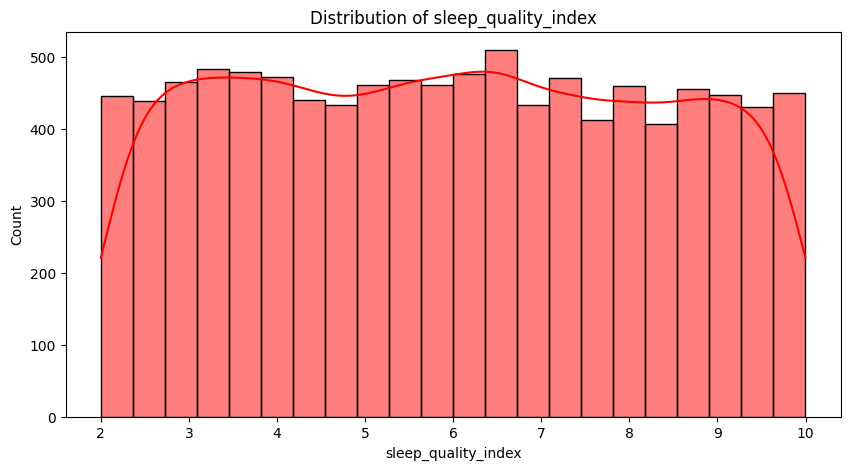

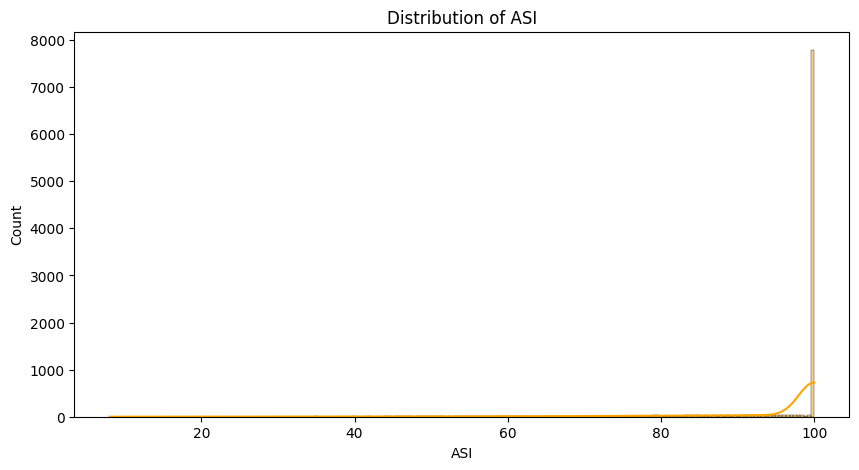

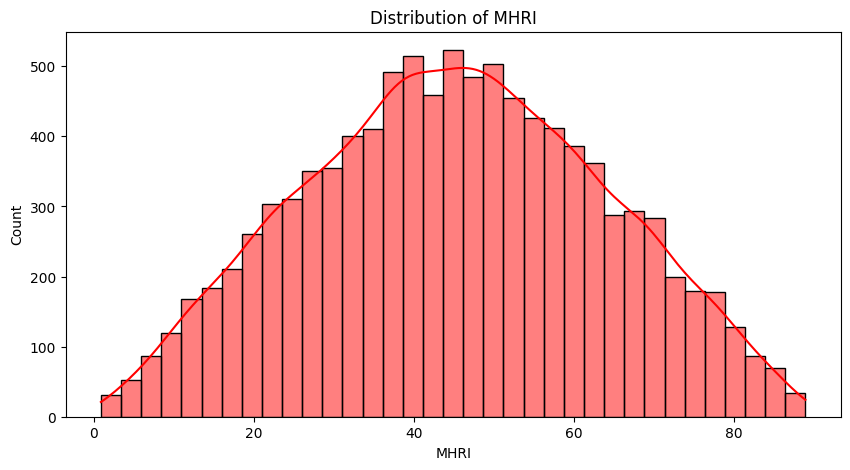

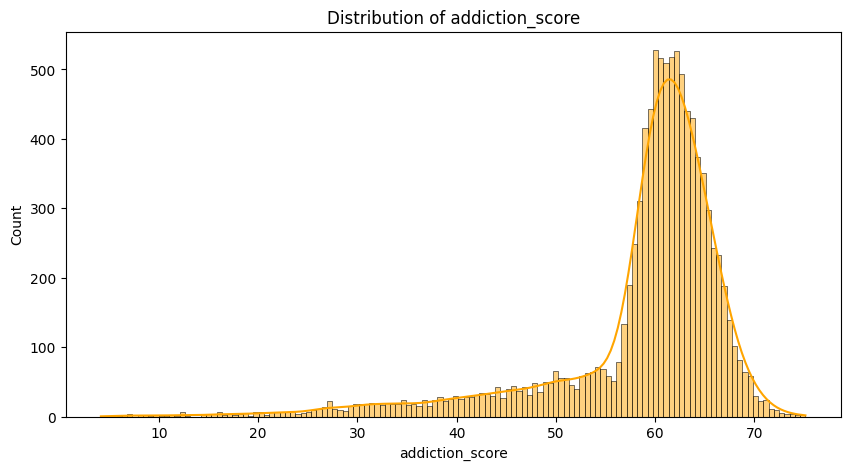

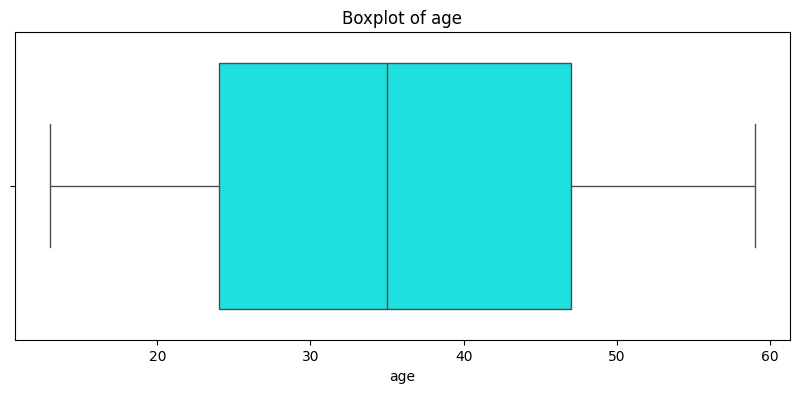

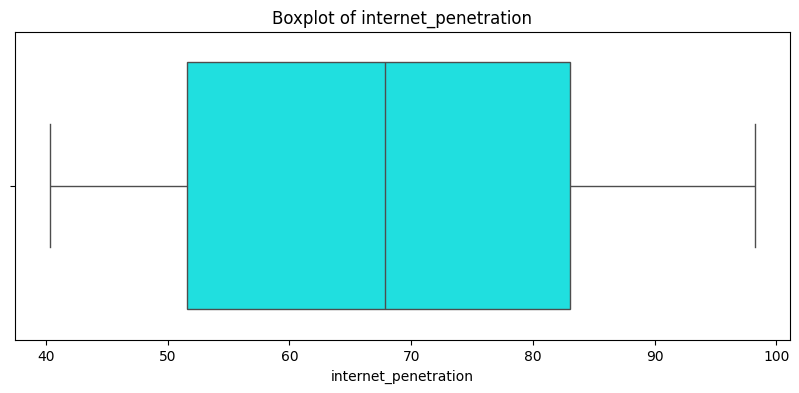

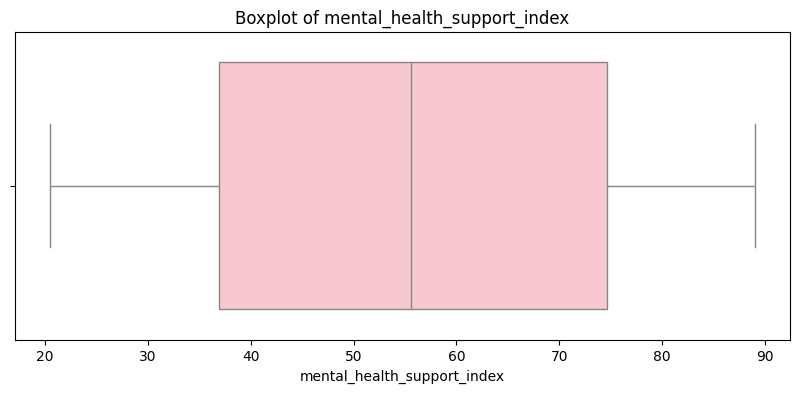

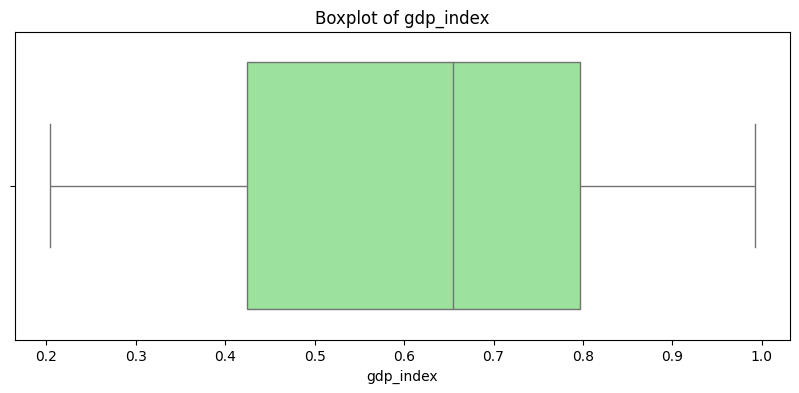

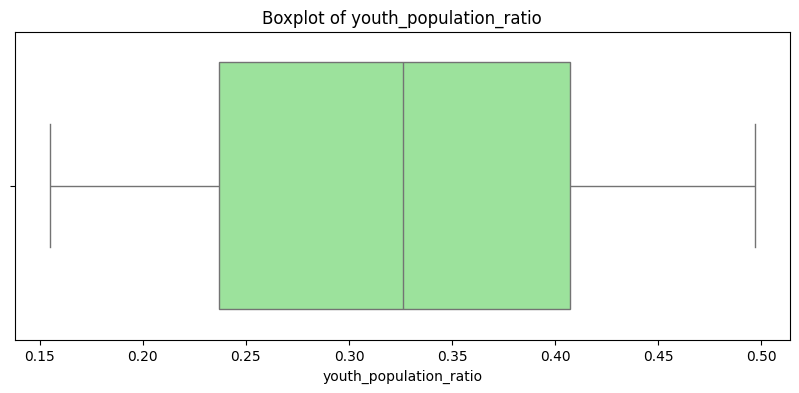

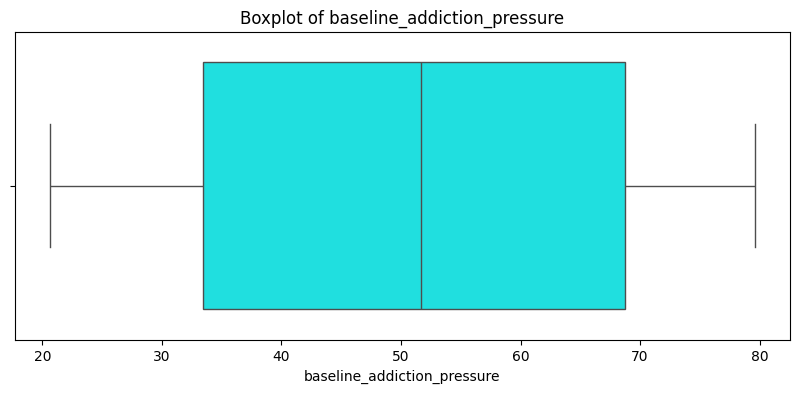

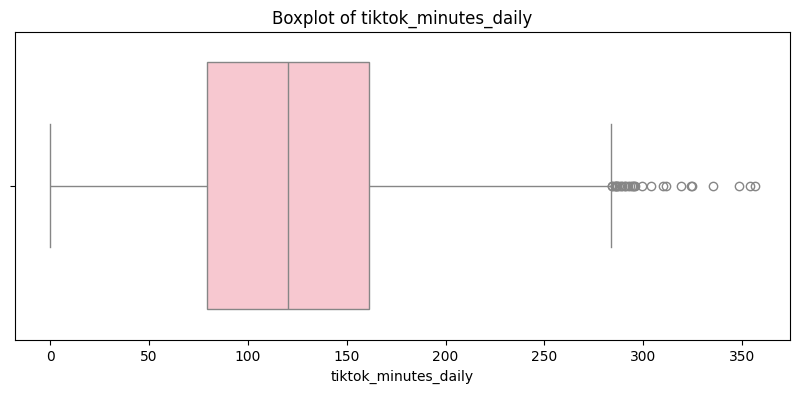

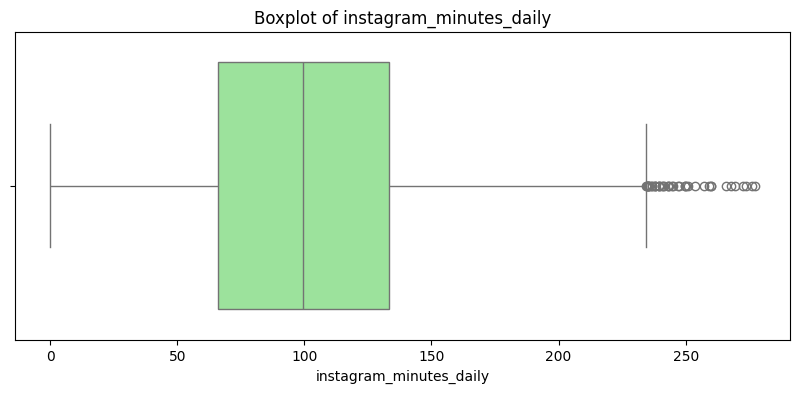

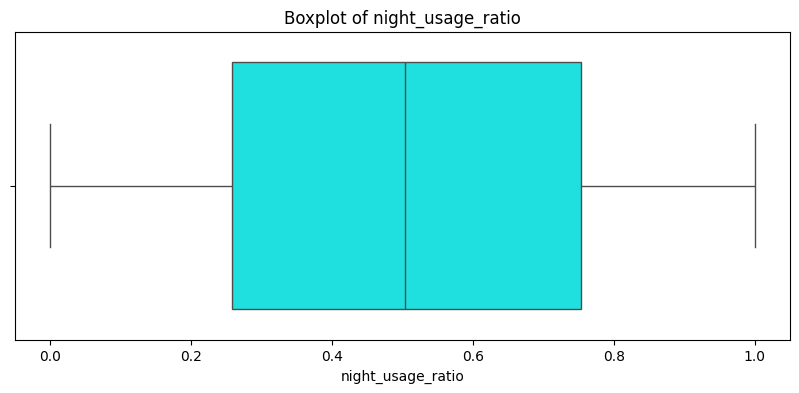

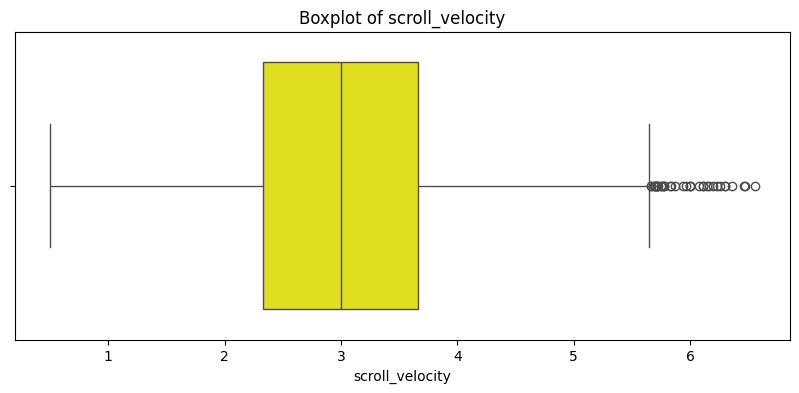

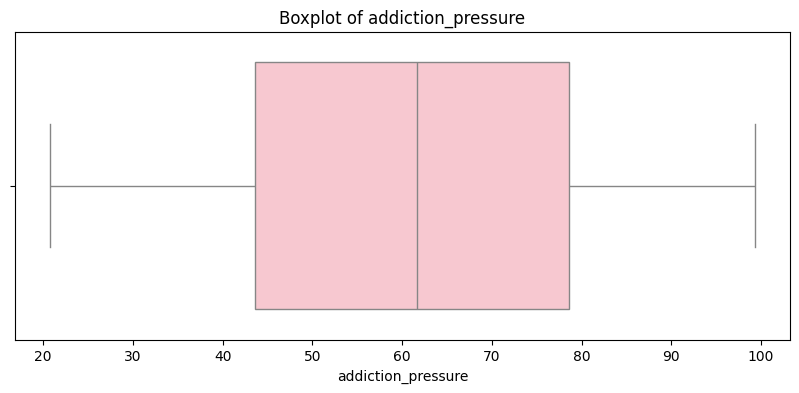

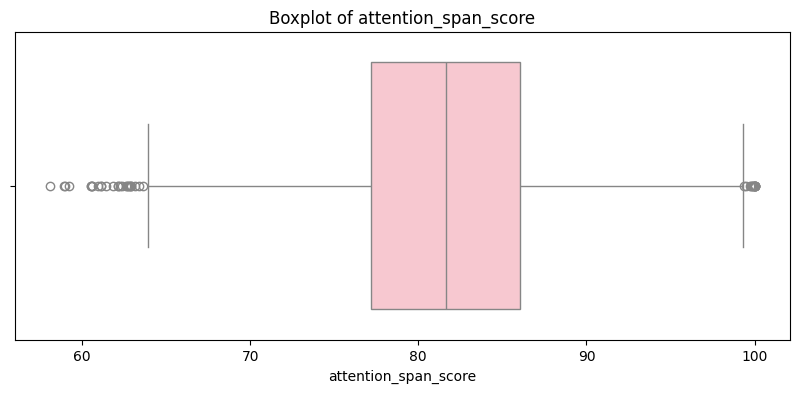

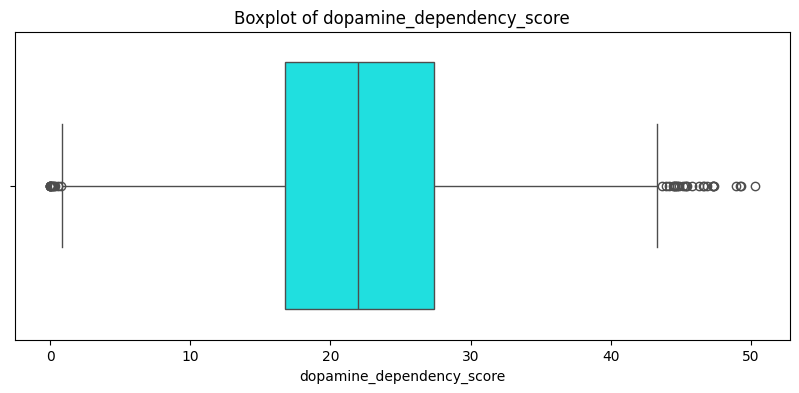

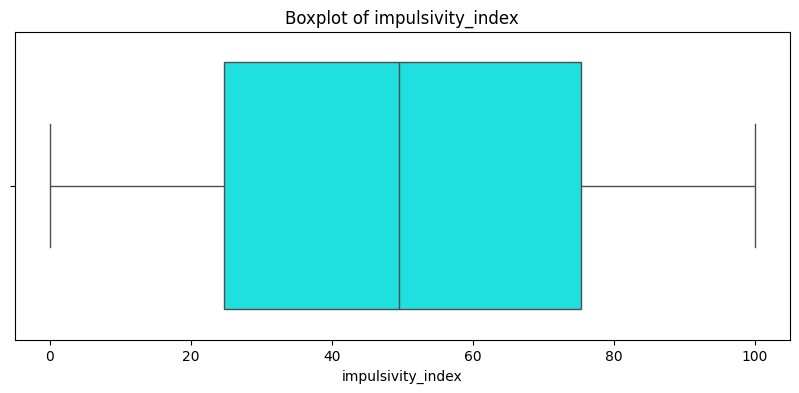

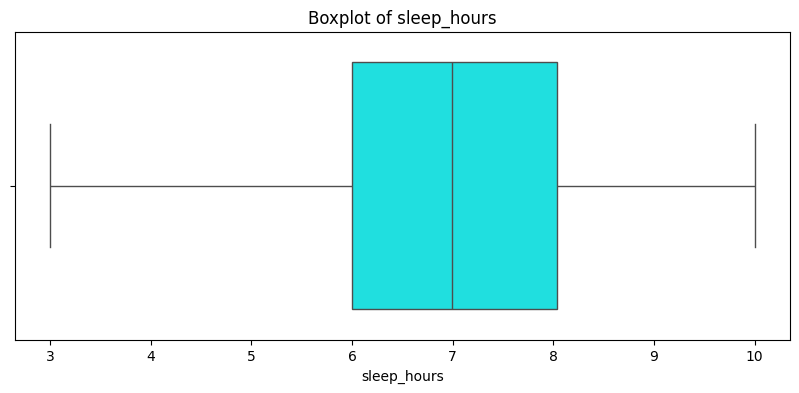

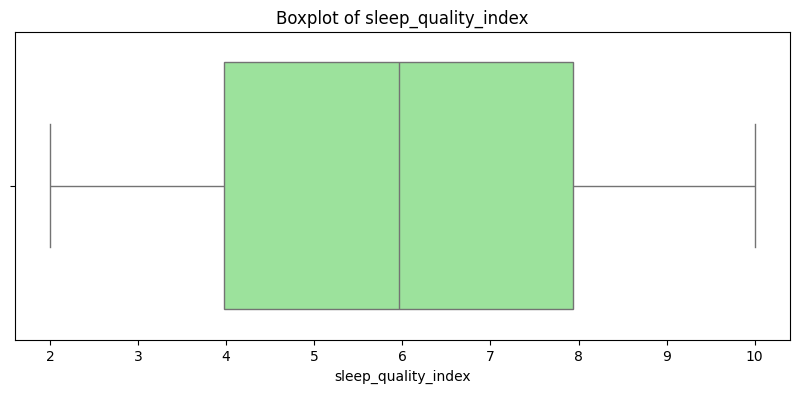

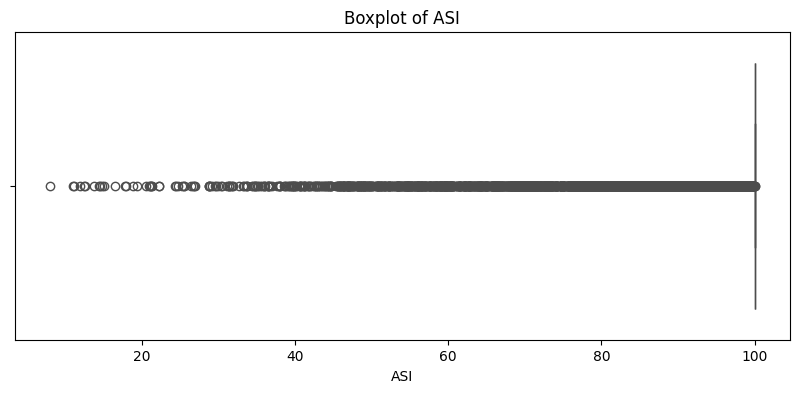

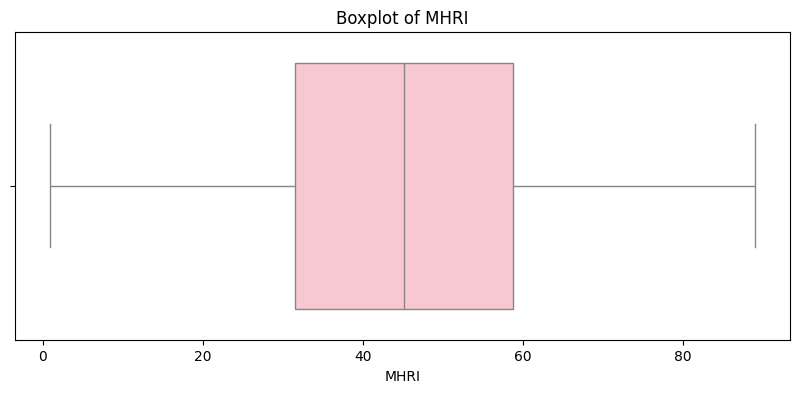

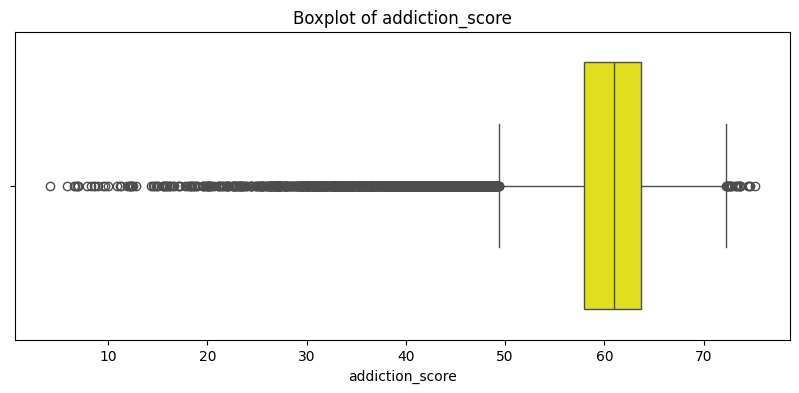

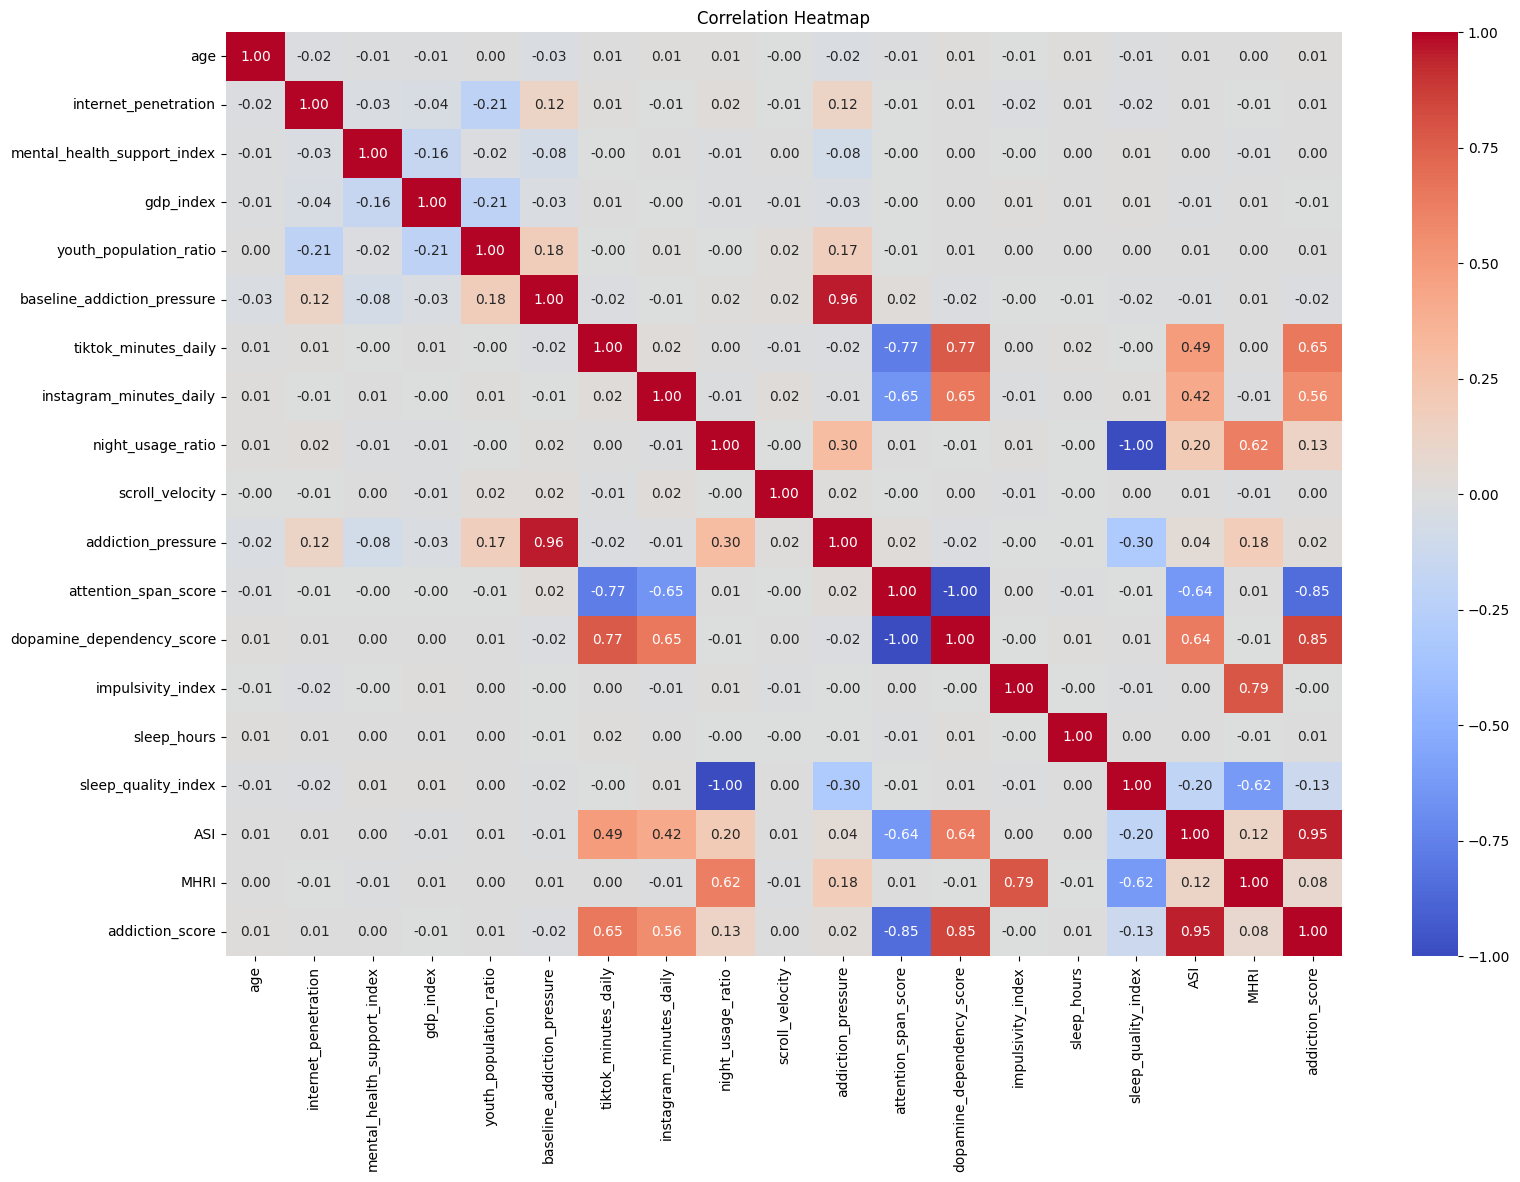

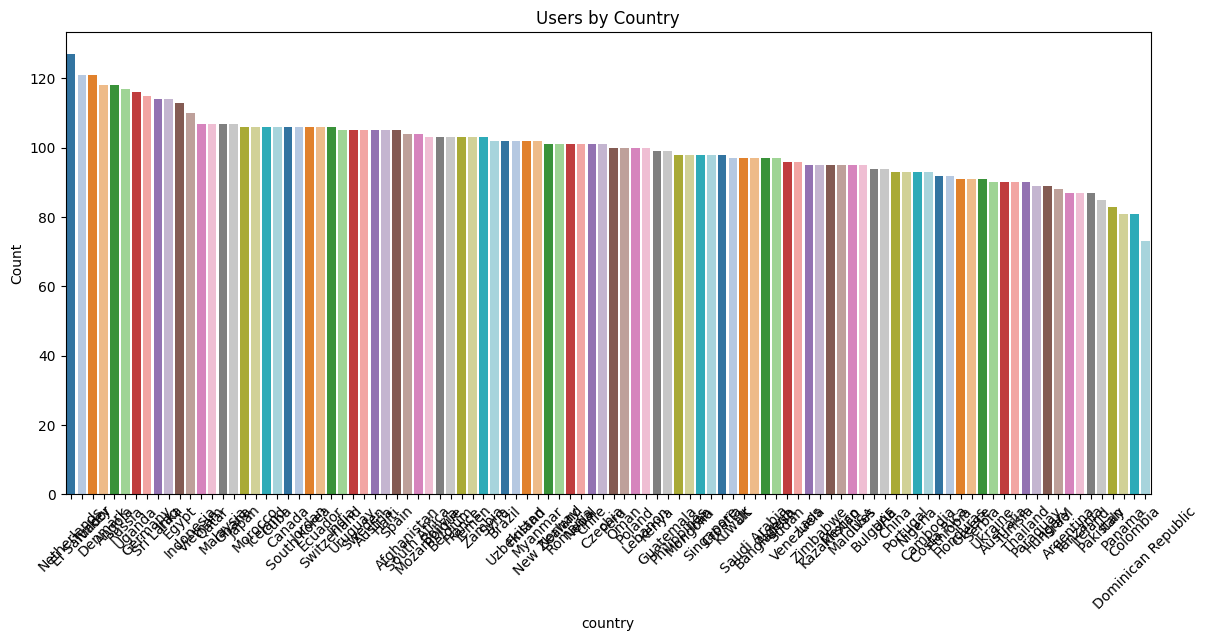

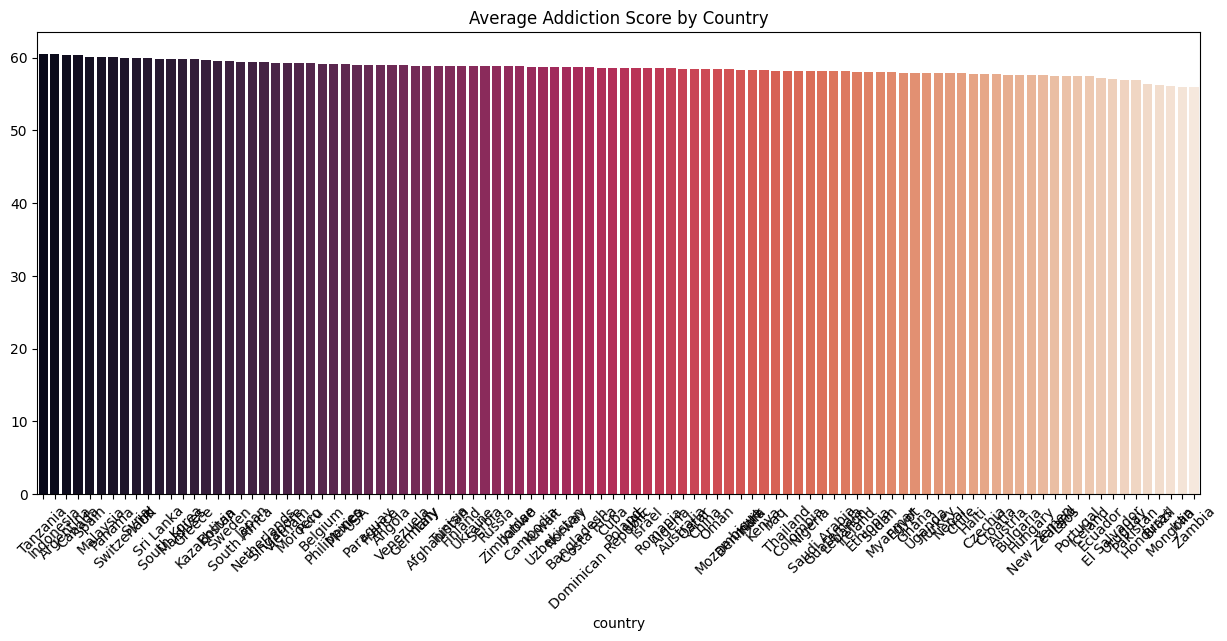

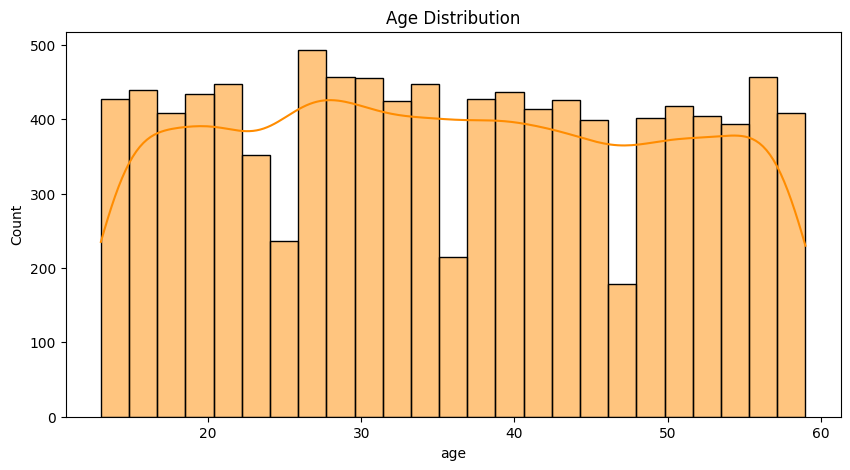

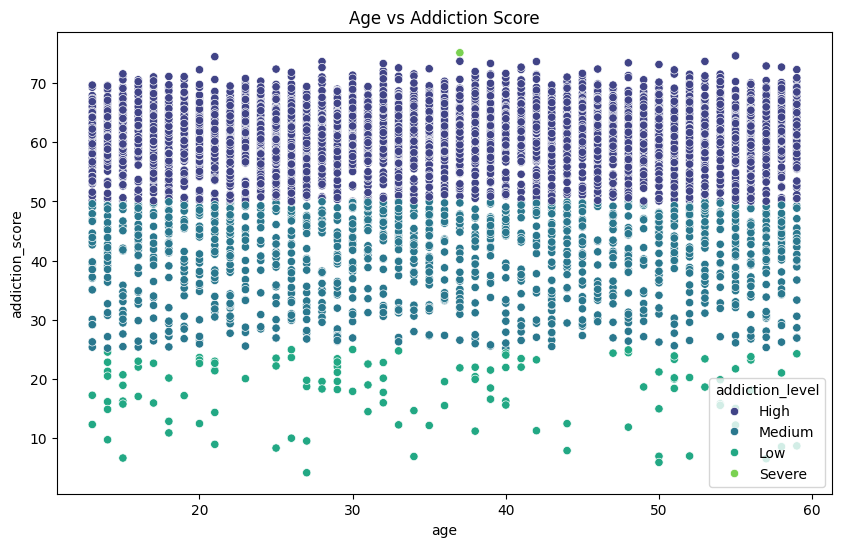

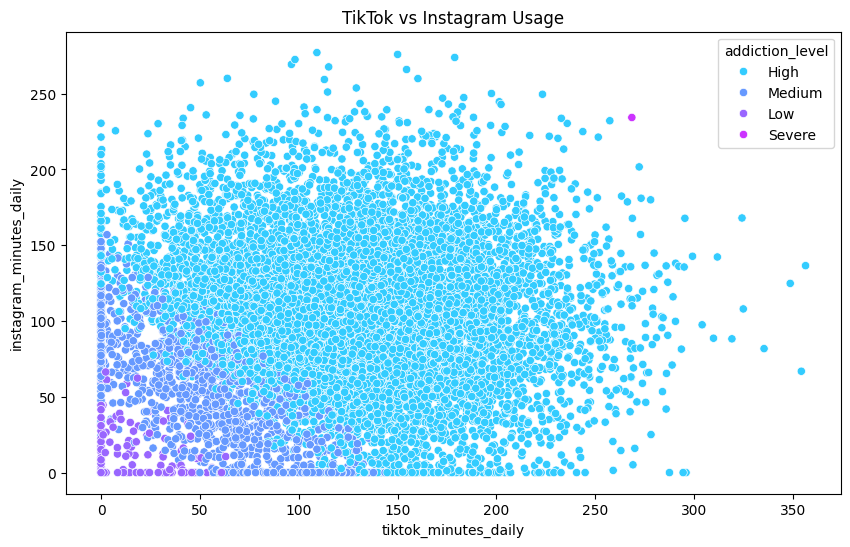

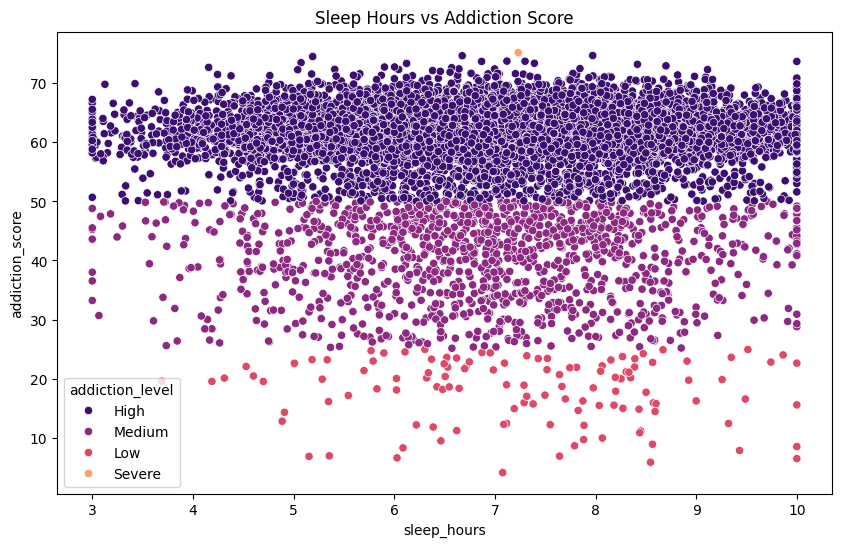

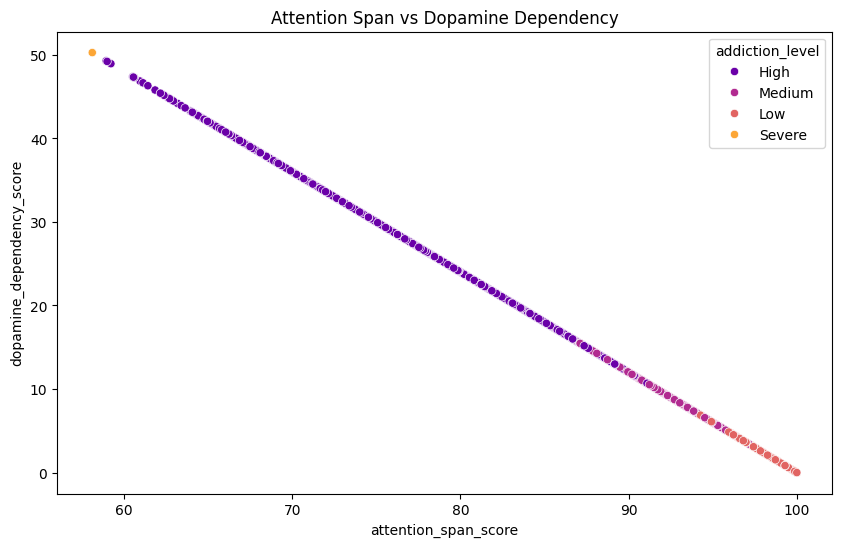

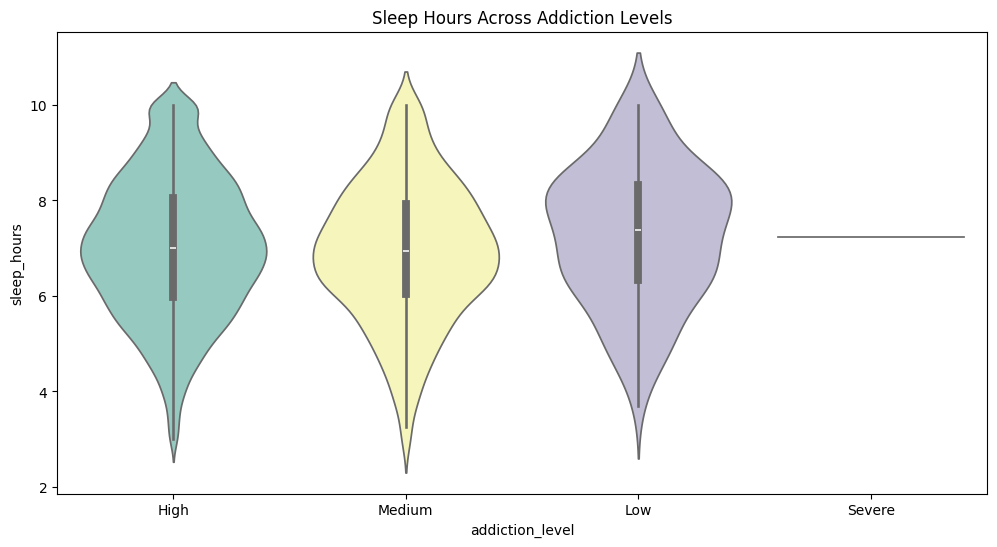

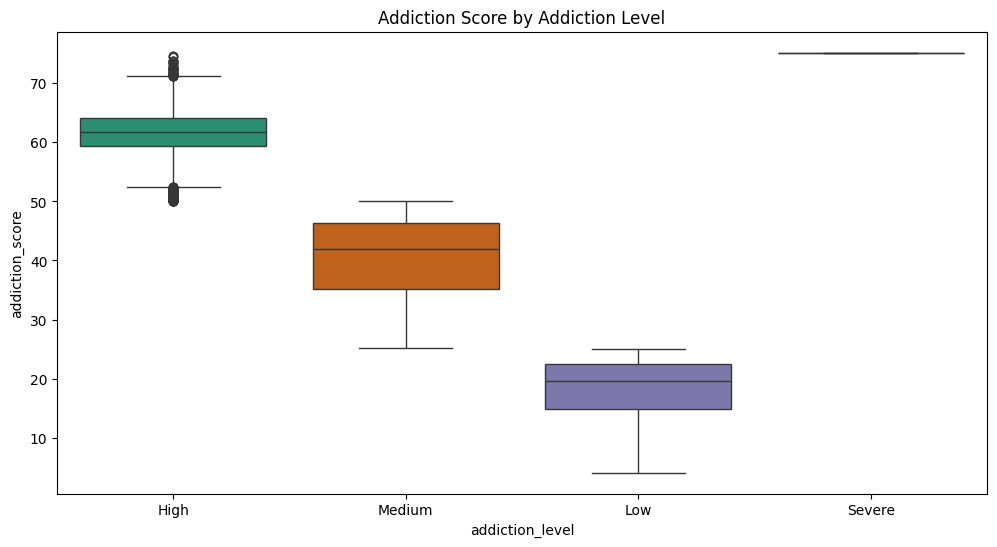

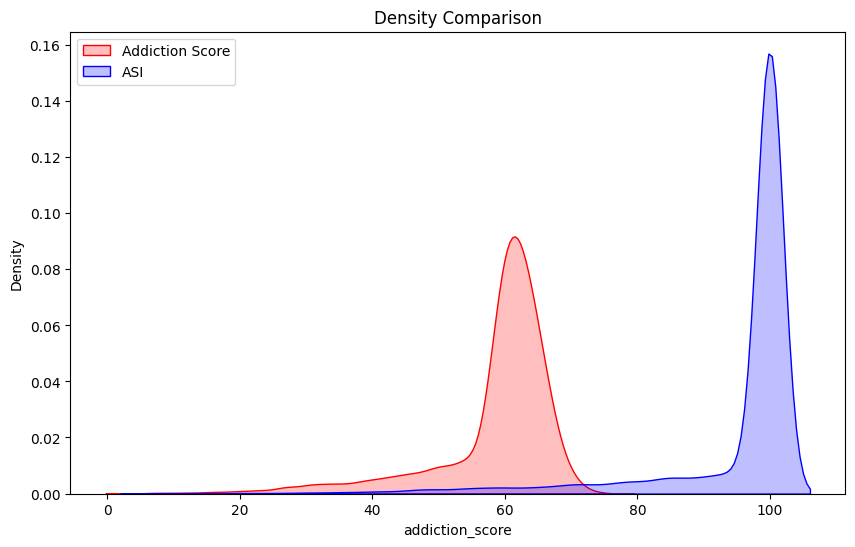

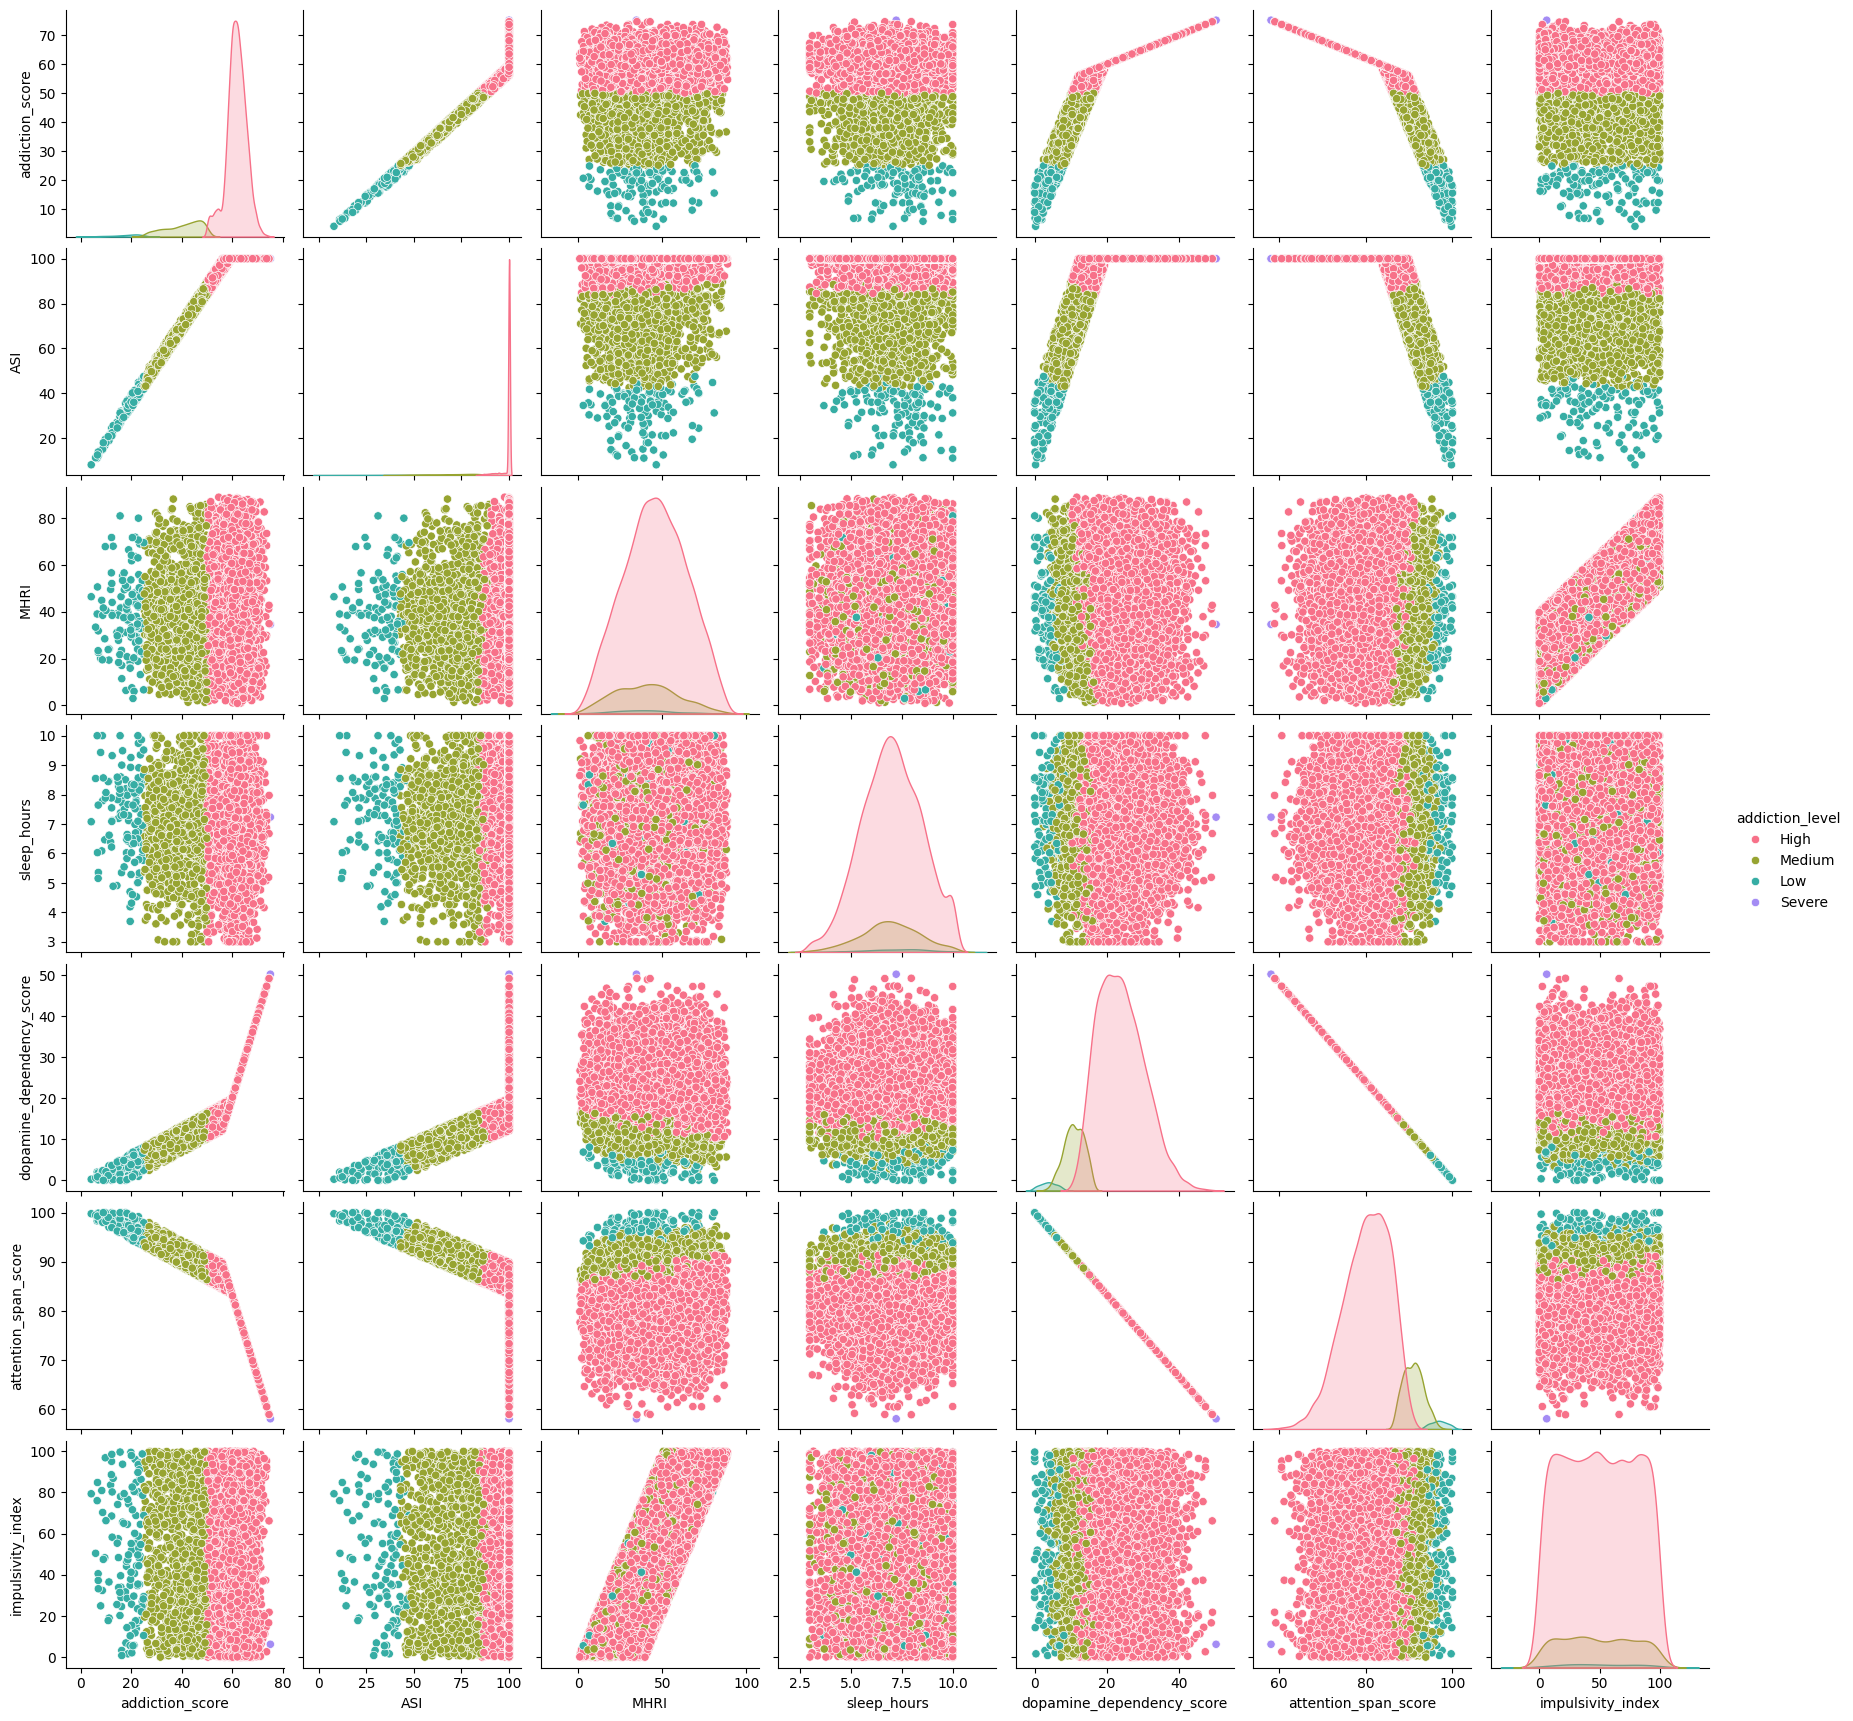

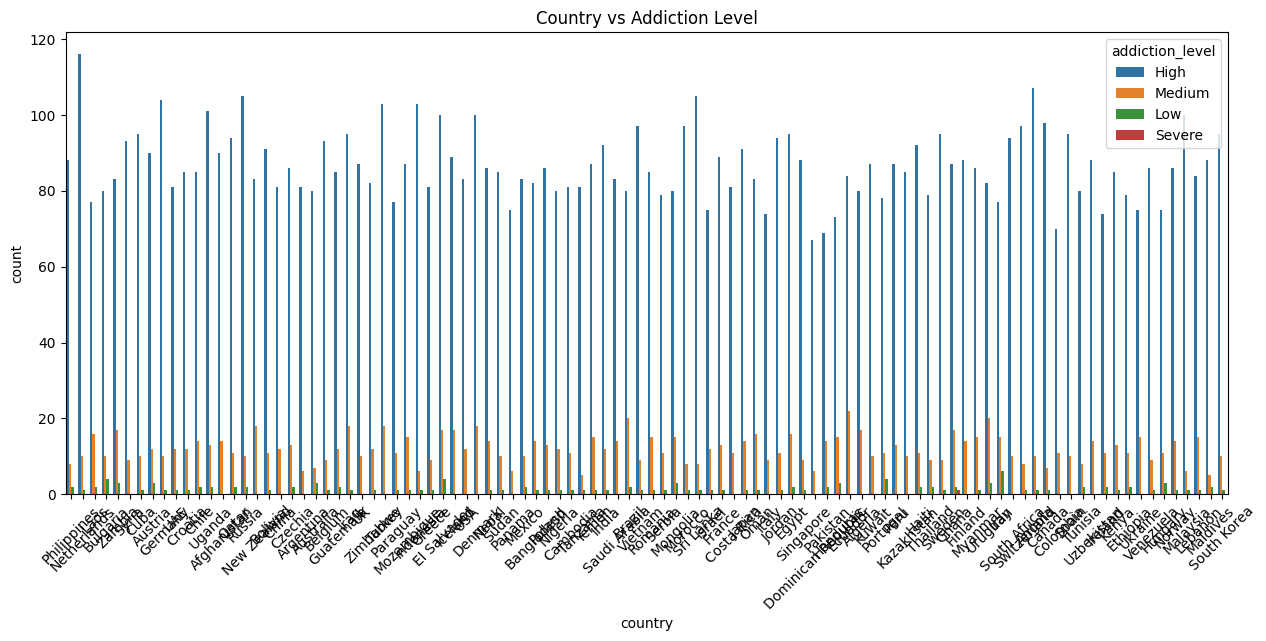

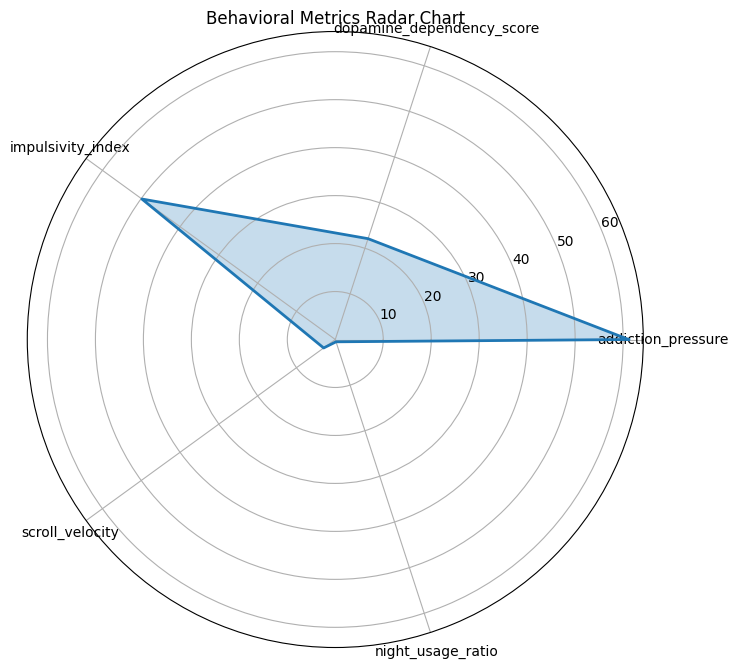

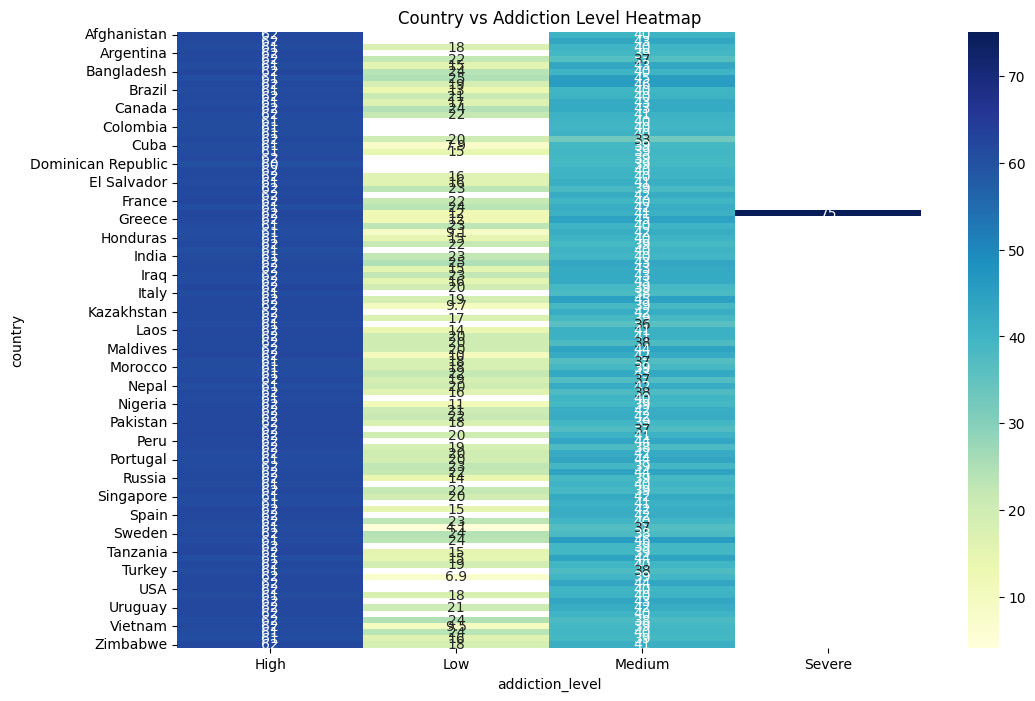

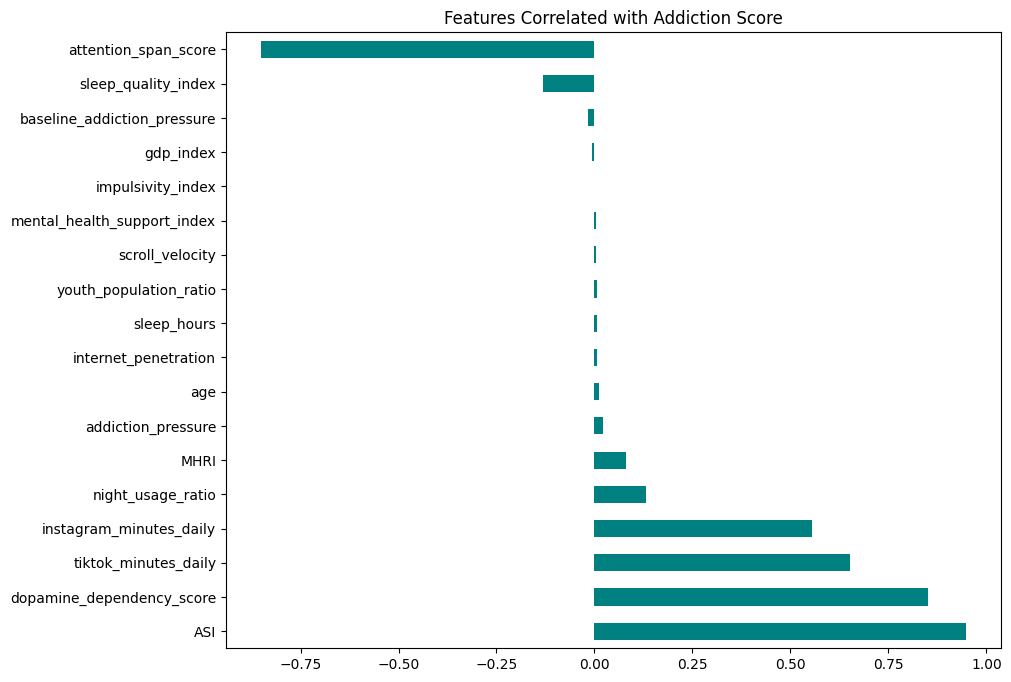

EDA Visualization Completed Successfully


In [13]:
# ==========================================
# MISSING VALUES VISUALIZATION
# ==========================================

plt.figure(figsize=(12,6))
sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)
plt.title('Missing Values Heatmap')
plt.show()

# ==========================================
# TARGET VARIABLE DISTRIBUTION
# ==========================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='addiction_level',
    data=df,
    palette='Set2'
)

plt.title('Addiction Level Distribution')
plt.xlabel('Addiction Level')
plt.ylabel('Count')
plt.show()

# ==========================================
# NUMERICAL FEATURES
# ==========================================

numerical_cols = [
    'age',
    'internet_penetration',
    'mental_health_support_index',
    'gdp_index',
    'youth_population_ratio',
    'baseline_addiction_pressure',
    'tiktok_minutes_daily',
    'instagram_minutes_daily',
    'night_usage_ratio',
    'scroll_velocity',
    'addiction_pressure',
    'attention_span_score',
    'dopamine_dependency_score',
    'impulsivity_index',
    'sleep_hours',
    'sleep_quality_index',
    'ASI',
    'MHRI',
    'addiction_score'
]

# ==========================================
# HISTOGRAMS
# ==========================================

for col in numerical_cols:

    plt.figure(figsize=(10,5))

    sns.histplot(
        df[col],
        kde=True,
        color=np.random.choice(
            ['blue','red','green','orange','purple']
        )
    )

    plt.title(f'Distribution of {col}')
    plt.show()

# ==========================================
# BOXPLOTS
# ==========================================

for col in numerical_cols:

    plt.figure(figsize=(10,4))

    sns.boxplot(
        x=df[col],
        color=np.random.choice(
            ['cyan','yellow','pink','lightgreen']
        )
    )

    plt.title(f'Boxplot of {col}')
    plt.show()

# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(18,12))

corr = df[numerical_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

# ==========================================
# COUNTRY DISTRIBUTION
# ==========================================

plt.figure(figsize=(14,6))

country_counts = df['country'].value_counts()

sns.barplot(
    x=country_counts.index,
    y=country_counts.values,
    palette='tab20'
)

plt.xticks(rotation=45)
plt.title('Users by Country')
plt.ylabel('Count')
plt.show()

# ==========================================
# AVERAGE ADDICTION SCORE BY COUNTRY
# ==========================================

country_addiction = (
    df.groupby('country')['addiction_score']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(15,6))

sns.barplot(
    x=country_addiction.index,
    y=country_addiction.values,
    palette='rocket'
)

plt.xticks(rotation=45)
plt.title('Average Addiction Score by Country')
plt.show()

# ==========================================
# AGE DISTRIBUTION
# ==========================================

plt.figure(figsize=(10,5))

sns.histplot(
    df['age'],
    bins=25,
    kde=True,
    color='darkorange'
)

plt.title('Age Distribution')
plt.show()

# ==========================================
# AGE VS ADDICTION SCORE
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='age',
    y='addiction_score',
    hue='addiction_level',
    palette='viridis'
)

plt.title('Age vs Addiction Score')
plt.show()

# ==========================================
# TIKTOK VS INSTAGRAM USAGE
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='tiktok_minutes_daily',
    y='instagram_minutes_daily',
    hue='addiction_level',
    palette='cool'
)

plt.title('TikTok vs Instagram Usage')
plt.show()

# ==========================================
# SLEEP HOURS VS ADDICTION SCORE
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='sleep_hours',
    y='addiction_score',
    hue='addiction_level',
    palette='magma'
)

plt.title('Sleep Hours vs Addiction Score')
plt.show()

# ==========================================
# ATTENTION SPAN VS DOPAMINE DEPENDENCY
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='attention_span_score',
    y='dopamine_dependency_score',
    hue='addiction_level',
    palette='plasma'
)

plt.title('Attention Span vs Dopamine Dependency')
plt.show()

# ==========================================
# VIOLIN PLOTS
# ==========================================

plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='addiction_level',
    y='sleep_hours',
    palette='Set3'
)

plt.title('Sleep Hours Across Addiction Levels')
plt.show()

# ==========================================
# BOXPLOT BY ADDICTION LEVEL
# ==========================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='addiction_level',
    y='addiction_score',
    palette='Dark2'
)

plt.title('Addiction Score by Addiction Level')
plt.show()

# ==========================================
# KDE PLOTS
# ==========================================

plt.figure(figsize=(10,6))

sns.kdeplot(
    df['addiction_score'],
    fill=True,
    color='red',
    label='Addiction Score'
)

sns.kdeplot(
    df['ASI'],
    fill=True,
    color='blue',
    label='ASI'
)

plt.legend()
plt.title('Density Comparison')
plt.show()

# ==========================================
# PAIRPLOT
# ==========================================

pair_cols = [
    'addiction_score',
    'ASI',
    'MHRI',
    'sleep_hours',
    'dopamine_dependency_score',
    'attention_span_score',
    'impulsivity_index'
]

sns.pairplot(
    df[pair_cols + ['addiction_level']],
    hue='addiction_level',
    palette='husl'
)

plt.show()

# ==========================================
# COUNTRY VS ADDICTION LEVEL
# ==========================================

plt.figure(figsize=(15,6))

sns.countplot(
    data=df,
    x='country',
    hue='addiction_level',
    palette='tab10'
)

plt.xticks(rotation=45)

plt.title('Country vs Addiction Level')
plt.show()

# ==========================================
# RADAR CHART
# ==========================================

features = [
    'addiction_pressure',
    'dopamine_dependency_score',
    'impulsivity_index',
    'scroll_velocity',
    'night_usage_ratio'
]

values = df[features].mean().tolist()

values += values[:1]

angles = [
    n / float(len(features)) * 2 * pi
    for n in range(len(features))
]

angles += angles[:1]

plt.figure(figsize=(8,8))

ax = plt.subplot(111, polar=True)

ax.plot(
    angles,
    values,
    linewidth=2
)

ax.fill(
    angles,
    values,
    alpha=0.25
)

plt.xticks(
    angles[:-1],
    features
)

plt.title('Behavioral Metrics Radar Chart')
plt.show()

# ==========================================
# ADDICTION LEVEL HEATMAP
# ==========================================

pivot = pd.pivot_table(
    df,
    values='addiction_score',
    index='country',
    columns='addiction_level',
    aggfunc='mean'
)

plt.figure(figsize=(12,8))

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlGnBu'
)

plt.title('Country vs Addiction Level Heatmap')
plt.show()

# ==========================================
# TOP CORRELATED FEATURES
# ==========================================

corr_target = (
    df[numerical_cols]
    .corr()['addiction_score']
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,8))

corr_target.drop('addiction_score').plot(
    kind='barh',
    color='teal'
)

plt.title(
    'Features Correlated with Addiction Score'
)

plt.show()

print("EDA Visualization Completed Successfully")

## Feature engineering

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    label_binarize
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [15]:
TARGET = "addiction_level"

In [16]:
if "user_id" in df.columns:
    df = df.drop(columns=["user_id"])

In [17]:
df = df.dropna(subset=[TARGET])

In [18]:
print("\nTarget Distribution:")
print(df[TARGET].value_counts())


Target Distribution:
addiction_level
High      8680
Medium    1198
Low        121
Severe       1
Name: count, dtype: int64


In [19]:
class_counts = df[TARGET].value_counts()

valid_classes = class_counts[class_counts >= 2].index

df = df[df[TARGET].isin(valid_classes)]

print("\nAfter Removing Rare Classes:")
print(df[TARGET].value_counts())


After Removing Rare Classes:
addiction_level
High      8680
Medium    1198
Low        121
Name: count, dtype: int64


In [20]:
X = df.drop(columns=[TARGET])
y = df[TARGET]


In [21]:
min_class_count = y.value_counts().min()

if min_class_count >= 2:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

else:

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )

print("\nTrain Shape:", X_train.shape)
print("Test Shape :", X_test.shape)



Train Shape: (7999, 21)
Test Shape : (2000, 21)


In [22]:
target_encoder = LabelEncoder()

y_train_enc = target_encoder.fit_transform(y_train)
y_test_enc = target_encoder.transform(y_test)

print("\nClasses:")
print(target_encoder.classes_)


Classes:
['High' 'Low' 'Medium']


In [23]:
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    exclude=["object", "category"]
).columns.tolist()

print("\nCategorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)



Categorical Columns:
['country']

Numerical Columns:
['age', 'year', 'internet_penetration', 'mental_health_support_index', 'gdp_index', 'youth_population_ratio', 'baseline_addiction_pressure', 'tiktok_minutes_daily', 'instagram_minutes_daily', 'night_usage_ratio', 'scroll_velocity', 'addiction_pressure', 'attention_span_score', 'dopamine_dependency_score', 'impulsivity_index', 'sleep_hours', 'sleep_quality_index', 'ASI', 'MHRI', 'addiction_score']


In [24]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [25]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=5000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=300,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "SVM":
        SVC(
            probability=True,
            random_state=42
        )
}



Logistic Regression
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1736
         Low       1.00      0.83      0.91        24
      Medium       0.98      0.99      0.98       240

    accuracy                           1.00      2000
   macro avg       0.99      0.94      0.96      2000
weighted avg       1.00      1.00      1.00      2000



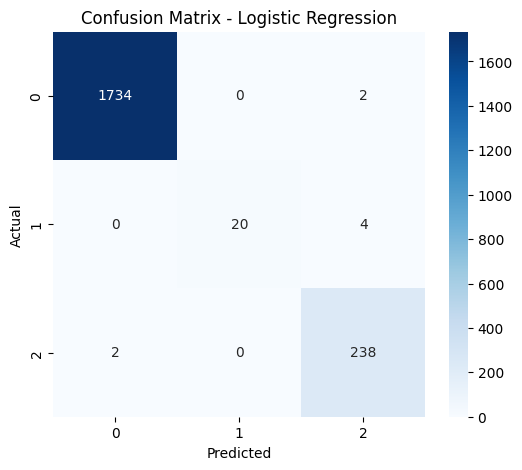


Decision Tree
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1736
         Low       1.00      1.00      1.00        24
      Medium       1.00      1.00      1.00       240

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



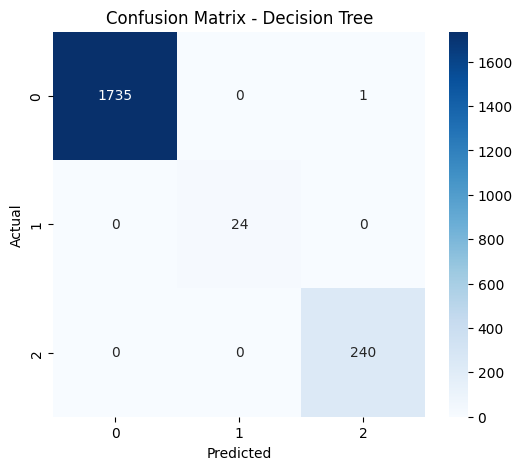


Random Forest
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1736
         Low       1.00      0.92      0.96        24
      Medium       0.99      1.00      1.00       240

    accuracy                           1.00      2000
   macro avg       1.00      0.97      0.98      2000
weighted avg       1.00      1.00      1.00      2000



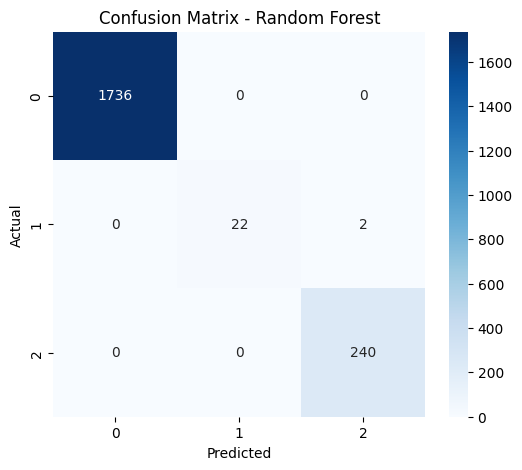


Extra Trees
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1736
         Low       1.00      0.79      0.88        24
      Medium       0.97      0.98      0.98       240

    accuracy                           0.99      2000
   macro avg       0.99      0.92      0.95      2000
weighted avg       0.99      0.99      0.99      2000



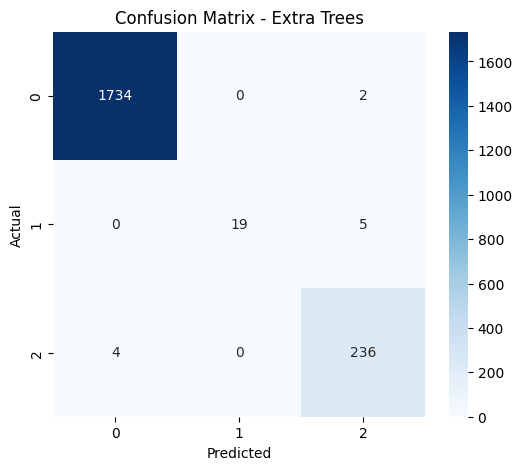


Gradient Boosting
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      1736
         Low       1.00      1.00      1.00        24
      Medium       1.00      1.00      1.00       240

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



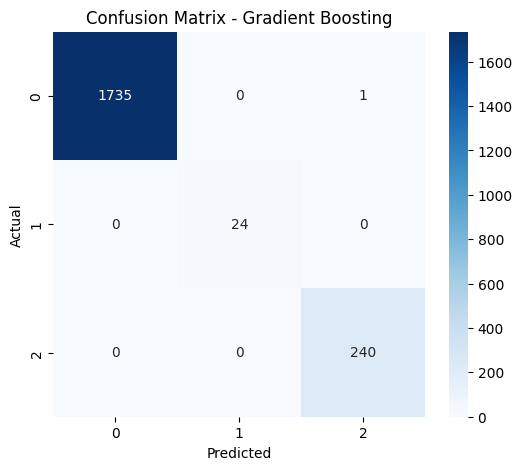


KNN
              precision    recall  f1-score   support

        High       0.98      1.00      0.99      1736
         Low       1.00      0.62      0.77        24
      Medium       0.94      0.84      0.89       240

    accuracy                           0.97      2000
   macro avg       0.97      0.82      0.88      2000
weighted avg       0.97      0.97      0.97      2000



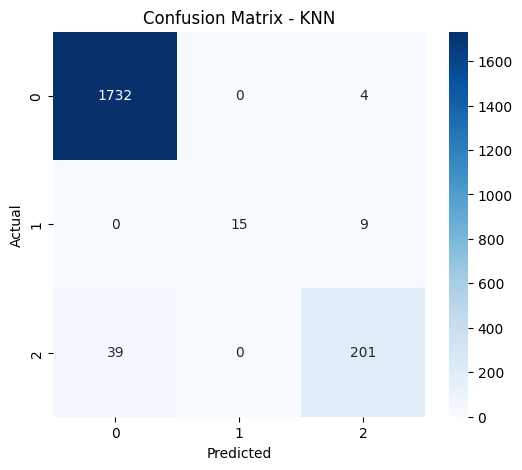


SVM
              precision    recall  f1-score   support

        High       0.99      1.00      1.00      1736
         Low       1.00      0.79      0.88        24
      Medium       0.95      0.96      0.95       240

    accuracy                           0.99      2000
   macro avg       0.98      0.92      0.94      2000
weighted avg       0.99      0.99      0.99      2000



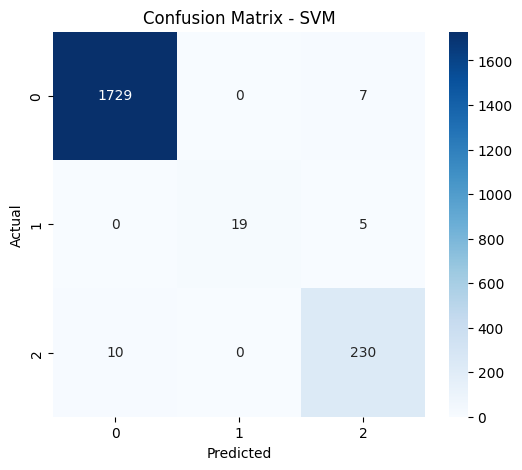

In [26]:
results = []

trained_models = {}

for model_name, model in models.items():

    print("\n" + "="*70)
    print(model_name)
    print("="*70)

    pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", model)
    ])

    pipeline.fit(
        X_train,
        y_train_enc
    )

    predictions = pipeline.predict(
        X_test
    )

    acc = accuracy_score(
        y_test_enc,
        predictions
    )

    results.append([
        model_name,
        acc
    ])

    trained_models[model_name] = pipeline

    print(
        classification_report(
            y_test_enc,
            predictions,
            target_names=target_encoder.classes_
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(
        y_test_enc,
        predictions
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()


Model Comparison:
                 Model  Accuracy
1        Decision Tree    0.9995
4    Gradient Boosting    0.9995
2        Random Forest    0.9990
0  Logistic Regression    0.9960
3          Extra Trees    0.9945
6                  SVM    0.9890
5                  KNN    0.9740


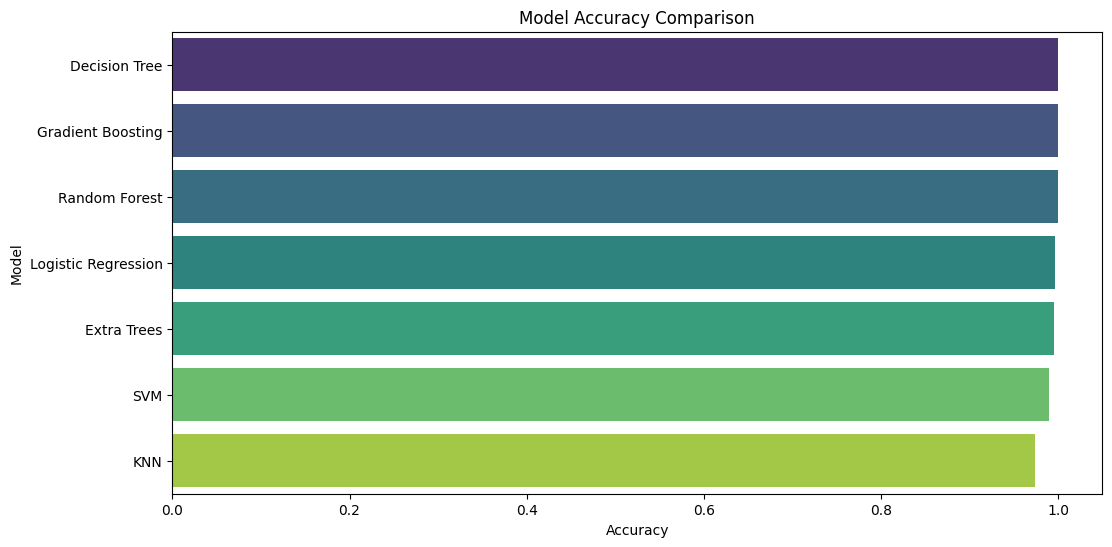


Best Model: Decision Tree


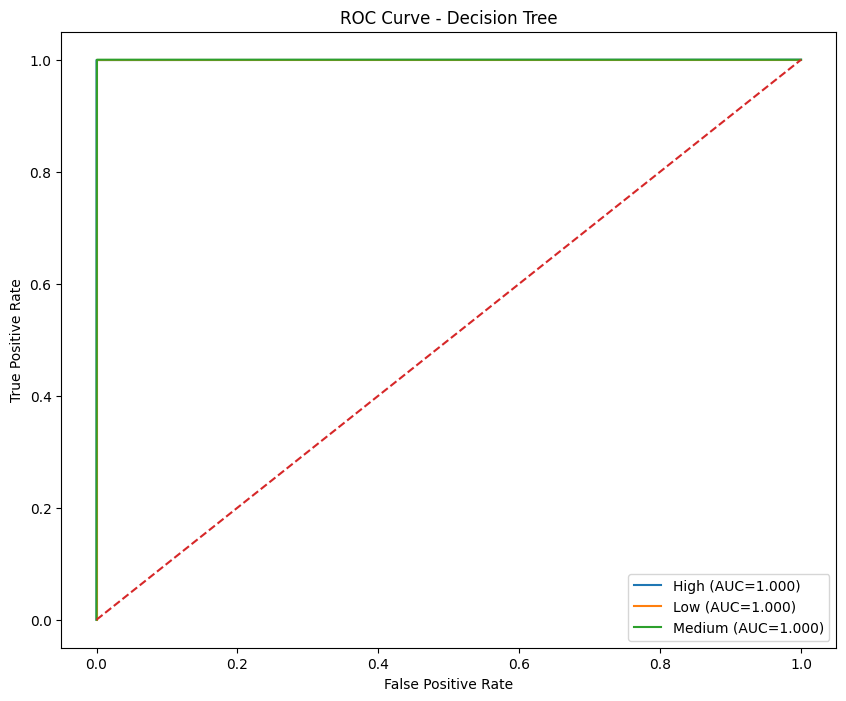


Final Metrics:
                 Model  Accuracy  Precision  Recall  F1 Score
1        Decision Tree    0.9995   0.999502  0.9995  0.999500
4    Gradient Boosting    0.9995   0.999502  0.9995  0.999500
2        Random Forest    0.9990   0.999008  0.9990  0.998980
0  Logistic Regression    0.9960   0.996049  0.9960  0.995926
3          Extra Trees    0.9945   0.994546  0.9945  0.994373
6                  SVM    0.9890   0.989058  0.9890  0.988881
5                  KNN    0.9740   0.973596  0.9740  0.972844

Pipeline Completed Successfully


In [27]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nModel Comparison:")
print(results_df)

# ==========================================================
# ACCURACY PLOT
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    hue="Model",
    legend=False,
    palette="viridis"
)

plt.title("Model Accuracy Comparison")

plt.show()

# ==========================================================
# BEST MODEL
# ==========================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print("\nBest Model:", best_model_name)

# ==========================================================
# ROC CURVE
# ==========================================================

try:

    n_classes = len(
        target_encoder.classes_
    )

    if n_classes > 1:

        y_test_bin = label_binarize(
            y_test_enc,
            classes=np.arange(n_classes)
        )

        probs = best_model.predict_proba(
            X_test
        )

        plt.figure(figsize=(10,8))

        for i in range(n_classes):

            fpr, tpr, _ = roc_curve(
                y_test_bin[:, i],
                probs[:, i]
            )

            roc_auc = auc(
                fpr,
                tpr
            )

            plt.plot(
                fpr,
                tpr,
                label=f"{target_encoder.classes_[i]} (AUC={roc_auc:.3f})"
            )

        plt.plot(
            [0,1],
            [0,1],
            linestyle="--"
        )

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")

        plt.title(
            f"ROC Curve - {best_model_name}"
        )

        plt.legend()

        plt.show()

except Exception as e:

    print("\nROC Curve Skipped")
    print("Reason:", e)

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

tree_models = [
    "Random Forest",
    "Extra Trees",
    "Gradient Boosting"
]

if best_model_name in tree_models:

    try:

        model = best_model.named_steps["model"]

        feature_names = (
            best_model.named_steps["prep"]
            .get_feature_names_out()
        )

        importance = model.feature_importances_

        imp_df = pd.DataFrame({
            "Feature": feature_names,
            "Importance": importance
        })

        imp_df = imp_df.sort_values(
            by="Importance",
            ascending=False
        ).head(20)

        plt.figure(figsize=(12,8))

        sns.barplot(
            data=imp_df,
            x="Importance",
            y="Feature",
            hue="Feature",
            legend=False,
            palette="rocket"
        )

        plt.title(
            f"Top 20 Important Features - {best_model_name}"
        )

        plt.show()

    except Exception as e:

        print("Feature Importance Error:", e)

# ==========================================================
# FINAL METRICS TABLE
# ==========================================================

metrics = []

for name, model in trained_models.items():

    pred = model.predict(X_test)

    report = classification_report(
        y_test_enc,
        pred,
        output_dict=True
    )

    metrics.append({

        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1 Score": report["weighted avg"]["f1-score"]
    })

metrics_df = pd.DataFrame(metrics)

metrics_df = metrics_df.sort_values(
    by="Accuracy",
    ascending=False
)

print("\nFinal Metrics:")
print(metrics_df)

# ==========================================================
# SAVE RESULTS
# ==========================================================

metrics_df.to_csv(
    "model_results.csv",
    index=False
)

print("\nPipeline Completed Successfully")

## Thank you....pls upvote!!!!!!!!!!!!